# Mode 2: Online Bayesian Meal Identification On Real CGM Data

This notebook tests the fixed-meal-parameter idea:

```text
A_meal = fixed pulse height for this meal
T_meal = fixed pulse width for this meal
p(A,T | CGM up to current time) is updated online
```

There is no Kalman state correction here. Every candidate `(A,T)` defines a full deterministic glucose trajectory. As new CGM values arrive, we update the posterior weight of each trajectory. This makes the meal identification interpretable: uncertainty moves over fixed meal-response parameters instead of drifting hidden parameters over time.


In [59]:
# =========================================================
# IMPORTS AND REAL DATA LOADING
# =========================================================

import os
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

ROOT_DIR = Path.cwd()
if ROOT_DIR.name == "nbs":
    ROOT_DIR = ROOT_DIR.parent

sys.path.append(str(ROOT_DIR))

from glucose_model.data.preprocess import (
    clean_response,
    clean_sleep,
    aggregate_activity,
    attach_context,
    interpolate_meal,
    normalize_context,
)
from glucose_model.data.dataset import GlucoseDataset


df_activity = pd.read_csv(ROOT_DIR / "data/processed/activity_data.csv")
df_sleep = pd.read_csv(ROOT_DIR / "data/processed/sleep_data.csv")
df_response = pd.read_csv(ROOT_DIR / "data/processed/t2d_long_format.csv")

print("Activity:", df_activity.shape)
print("Sleep:   ", df_sleep.shape)
print("Response:", df_response.shape)
print("time_meal range:", df_response["time_meal"].min(), df_response["time_meal"].max())


Activity: (16217, 8)
Sleep:    (687, 8)
Response: (143118, 33)
time_meal range: -30 360


/tmp/ipykernel_2878/34112815.py:35: DtypeWarning: Columns (0: Snack pre/post) have mixed types. Specify dtype option on import or set low_memory=False.
  df_response = pd.read_csv(ROOT_DIR / "data/processed/t2d_long_format.csv")


In [ ]:
# =========================================================
# BUILD REAL MEAL WINDOWS WITH PREMEAL TIME PRESERVED
# =========================================================


def build_meal_trajectories_with_premeal(df, min_time=-30, min_post_time=60):
    meals = []

    for meal_id, g in df.groupby("abs_ID"):
        g = g.sort_values("time_meal")

        t = pd.to_numeric(g["time_meal"], errors="coerce").to_numpy(dtype=float)
        glucose = pd.to_numeric(g["Glucose"], errors="coerce").to_numpy(dtype=float)

        valid = np.isfinite(t) & np.isfinite(glucose)
        t = t[valid]
        glucose = glucose[valid]

        if len(t) < 4:
            continue
        if np.nanmin(t) > min_time or np.nanmax(t) < min_post_time:
            continue

        meal = {
            "person_id": int(g["ID"].iloc[0]),
            "meal_id": meal_id,
            "meal_type": g["Meal type"].iloc[0],
            "meal": {
                "carbs": float(g["CHO_g"].iloc[0]),
                "fat": float(g["Fat_g"].iloc[0]),
                "protein": float(g["Prot_g"].iloc[0]),
            },
            "time": t,
            "glucose": glucose,
            "day": g["Day number"].iloc[0],
        }

        meals.append(meal)

    return meals


df_response_clean = clean_response(df_response)
df_sleep_clean = clean_sleep(df_sleep)
df_activity_agg = aggregate_activity(df_activity)

meals = build_meal_trajectories_with_premeal(df_response_clean)
meals = attach_context(meals, df_sleep_clean, df_activity_agg)

t_grid = np.arange(-30, 181, 5)
meals_interp = [interpolate_meal(m, t_grid) for m in meals]
meals_interp, context_mean, context_std = normalize_context(meals_interp)

person_ids = sorted(set(m["person_id"] for m in meals_interp))
person_to_idx = {pid: i for i, pid in enumerate(person_ids)}
for m in meals_interp:
    m["person_idx"] = person_to_idx[m["person_id"]]

mode2_dataset = GlucoseDataset(meals_interp)

print(f"Meal windows: {len(mode2_dataset)}")
print(f"People:       {len(person_ids)}")
print(f"Time grid:    {t_grid[0]} to {t_grid[-1]} min, n={len(t_grid)}")


In [ ]:
# =========================================================
# TRAIN / TEST SPLIT BY PERSON
# =========================================================


def split_meals_by_person(ds, train_frac=0.70, min_train=5, min_test=2):
    by_person = defaultdict(list)

    for idx, meal in enumerate(ds.meals):
        by_person[int(meal["person_id"])].append(idx)

    train_idx = []
    test_idx = []

    for person_id, indices in by_person.items():
        indices = list(indices)
        n = len(indices)

        if n < min_train + min_test:
            continue

        n_train = int(np.floor(train_frac * n))
        n_train = min(max(n_train, min_train), n - min_test)

        train_idx.extend(indices[:n_train])
        test_idx.extend(indices[n_train:])

    return train_idx, test_idx


train_idx, test_idx = split_meals_by_person(mode2_dataset)
print(f"Train meals: {len(train_idx)}")
print(f"Test meals:  {len(test_idx)}")


Train meals: 1448
Test meals:  678


In [ ]:
# =========================================================
# SHARED HELPERS
# =========================================================

ACKERMAN_DEFAULT = {
    # Damped oscillator response shape.
    "period": 170.0,
    "zeta": 0.70,
    "k_b": 0.001,

    # Population-level starting guesses for fixed meal parameters.
    "A0": 0.10,
    "T0": 55.0,
}

PARAM_BOUNDS = {
    "A": (0.001, 0.80),
    "T": (5.0, 180.0),
}


def sample_from_dataset(ds, idx):
    sample = ds[idx]
    raw = ds.meals[idx]

    return {
        "idx": idx,
        "meal_id": raw.get("meal_id", idx),
        "meal_type": raw.get("meal_type", "unknown"),
        "person_id": int(sample["person_id"]),
        "person_idx": int(sample["person_idx"]),
        "meal": {
            "carbs": float(sample["meal"]["carbs"]),
            "fat": float(sample["meal"]["fat"]),
            "protein": float(sample["meal"]["protein"]),
        },
        "context": np.asarray(sample["context"], dtype=float),
        "time": np.asarray(sample["time"], dtype=float),
        "glucose": np.asarray(sample["glucose"], dtype=float),
    }


def premeal_summary(sample):
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    pre = time < 0

    if np.sum(pre) < 2:
        baseline = float(glucose[0])
        slope = 0.0
    else:
        baseline = float(np.median(glucose[pre]))
        slope = float(np.polyfit(time[pre], glucose[pre], 1)[0])

    return baseline, slope


def response_metrics(time, glucose_curve, baseline=None, threshold=180.0):
    time = np.asarray(time, dtype=float)
    glucose_curve = np.asarray(glucose_curve, dtype=float)
    post = time >= 0

    if baseline is None:
        baseline = float(np.median(glucose_curve[time < 0])) if np.any(time < 0) else float(glucose_curve[0])

    post_time = time[post]
    post_glucose = glucose_curve[post]
    delta = post_glucose - baseline

    return {
        "baseline": baseline,
        "peak": float(np.max(post_glucose)),
        "peak_delta": float(np.max(delta)),
        "iAUC": float(np.trapz(np.maximum(delta, 0.0), post_time)),
        "time_above_180": float(np.sum(post_glucose > threshold) * np.median(np.diff(time))),
    }


def wide_pulse(t, T, edge=3.0):
    z1 = np.clip(t / edge, -60.0, 60.0)
    z2 = np.clip((T - t) / edge, -60.0, 60.0)
    return (1.0 / (1.0 + np.exp(-z1))) * (1.0 / (1.0 + np.exp(-z2)))


def logsumexp(values):
    values = np.asarray(values, dtype=float)
    max_value = np.max(values)
    return float(max_value + np.log(np.sum(np.exp(values - max_value))))


def softmax_log(log_values):
    return np.exp(log_values - logsumexp(log_values))


def weighted_quantile(values, weights, probs):
    values = np.asarray(values, dtype=float).reshape(-1)
    weights = np.asarray(weights, dtype=float).reshape(-1)
    probs = np.asarray(probs, dtype=float)

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cdf = np.cumsum(weights)
    cdf = cdf / cdf[-1]
    return np.interp(probs, cdf, values)


In [ ]:
# =========================================================
# DETERMINISTIC ACKERMAN FORECAST FOR FIXED A/T
# =========================================================


def rollout_ackerman_pulse(sample, theta=None, A_meal=None, T_meal=None):
    """
    Deterministic forecast for one fixed meal parameter pair.

    State:
      G = glucose deviation from baseline
      V = response velocity
      B = slowly moving baseline

    A_meal is the fixed pulse height. T_meal is the fixed pulse width.
    """
    theta = {**ACKERMAN_DEFAULT, **(theta or {})}

    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)

    A_meal = ACKERMAN_DEFAULT["A0"] if A_meal is None else float(A_meal)
    T_meal = ACKERMAN_DEFAULT["T0"] if T_meal is None else float(T_meal)
    A_meal = float(np.clip(A_meal, *PARAM_BOUNDS["A"]))
    T_meal = float(np.clip(T_meal, *PARAM_BOUNDS["T"]))

    baseline0, pre_slope = premeal_summary(sample)

    omega = 2.0 * np.pi / theta["period"]
    zeta = theta["zeta"]
    k_b = theta["k_b"]

    x = np.array([
        glucose[0] - baseline0,
        pre_slope,
        baseline0,
    ], dtype=float)

    pred = []

    for i, t in enumerate(time):
        pred.append(float(x[0] + x[2]))

        if i == len(time) - 1:
            break

        dt = float(time[i + 1] - time[i])
        n_steps = max(1, int(np.ceil(abs(dt))))
        h = dt / n_steps

        for substep in range(n_steps):
            t_sub = float(t) + substep * h
            pulse = wide_pulse(t_sub, T_meal)

            G, V, B = x

            dG = V
            dV = -(omega ** 2) * G - 2.0 * zeta * omega * V + A_meal * pulse
            dB = -k_b * (B - baseline0)

            x = np.array([
                G + h * dG,
                V + h * dV,
                B + h * dB,
            ], dtype=float)

    pred = np.asarray(pred, dtype=float)

    return {
        "time": time,
        "glucose_obs": glucose,
        "glucose_pred": pred,
        "prediction_residual": glucose - pred,
        "A_meal": A_meal,
        "T_meal": T_meal,
        "theta": theta,
    }


In [ ]:
# =========================================================
# STAGE 1: INFER COMPLETED-MEAL A/T LABELS AND TRAIN PREMEAL PRIORS
# =========================================================

FEATURE_NAMES = [
    "intercept",
    "carbs",
    "fat",
    "protein",
    "premeal_level",
    "premeal_slope",
    "breakfast",
    "lunch",
    "dinner",
]

# Conservative biological constraints for the first prediction model:
#   - carbohydrate should not reduce meal-response amplitude A
#   - fat/protein should not directly reduce A; their main effect is through T
#   - fat/protein should not shorten T
USE_BIOLOGICAL_PRIOR_CONSTRAINTS = True


def meal_feature_vector(sample):
    baseline, slope = premeal_summary(sample)
    meal = sample["meal"]
    context = np.asarray(sample.get("context", np.zeros(5)), dtype=float)
    meal_type = context[2:5] if len(context) >= 5 else np.zeros(3)

    return np.array([
        1.0,
        (meal["carbs"] - 70.0) / 50.0,
        (meal["fat"] - 20.0) / 15.0,
        (meal["protein"] - 20.0) / 15.0,
        (baseline - 120.0) / 40.0,
        slope / 0.20,
        *meal_type,
    ], dtype=float)


def fit_ridge(X, y, l2=1.0, sample_weight=None):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    if sample_weight is None:
        w = np.ones(len(y), dtype=float)
    else:
        w = np.asarray(sample_weight, dtype=float)
        w = w / max(np.mean(w), 1e-12)

    Xw = X * np.sqrt(w)[:, None]
    yw = y * np.sqrt(w)
    penalty = l2 * np.eye(X.shape[1])
    penalty[0, 0] = 0.0
    return np.linalg.solve(Xw.T @ Xw + penalty, Xw.T @ yw)


def predict_from_ridge(x, coef):
    return float(np.asarray(x) @ np.asarray(coef))


def balanced_label_indices(ds, indices, max_meals=80, random_state=0):
    rng = np.random.default_rng(random_state)
    by_person = defaultdict(list)

    for idx in indices:
        person_id = int(ds.meals[idx]["person_id"])
        by_person[person_id].append(idx)

    for person_indices in by_person.values():
        rng.shuffle(person_indices)

    selected = []
    person_ids = sorted(by_person)

    while len(selected) < max_meals:
        added = False
        for person_id in person_ids:
            if by_person[person_id]:
                selected.append(by_person[person_id].pop(0))
                added = True
                if len(selected) >= max_meals:
                    break
        if not added:
            break

    return selected


def summarize_at_posterior(A_grid, T_grid, posterior):
    posterior = np.asarray(posterior, dtype=float)
    A_grid = np.asarray(A_grid, dtype=float)
    T_grid = np.asarray(T_grid, dtype=float)

    posterior = posterior / np.sum(posterior)
    A_marginal = posterior.sum(axis=0)
    T_marginal = posterior.sum(axis=1)
    map_idx = np.unravel_index(np.argmax(posterior), posterior.shape)

    A_mean = float(np.sum(A_marginal * A_grid))
    T_mean = float(np.sum(T_marginal * T_grid))
    A_sd = float(np.sqrt(np.sum(A_marginal * (A_grid - A_mean) ** 2)))
    T_sd = float(np.sqrt(np.sum(T_marginal * (T_grid - T_mean) ** 2)))
    A_q05, A_q50, A_q95 = weighted_quantile(A_grid, A_marginal, [0.05, 0.50, 0.95])
    T_q05, T_q50, T_q95 = weighted_quantile(T_grid, T_marginal, [0.05, 0.50, 0.95])

    return {
        "A_map": float(A_grid[map_idx[1]]),
        "T_map": float(T_grid[map_idx[0]]),
        "A_mean": A_mean,
        "T_mean": T_mean,
        "A_sd": A_sd,
        "T_sd": T_sd,
        "A_q05": float(A_q05),
        "A_q50": float(A_q50),
        "A_q95": float(A_q95),
        "T_q05": float(T_q05),
        "T_q50": float(T_q50),
        "T_q95": float(T_q95),
    }


def infer_completed_meal_at_posterior(sample, theta=None, A_grid=None, T_grid=None, sigma=12.0):
    """
    Full-meal posterior label p(A,T | completed CGM) for one historical meal.

    These posterior labels are what the premeal prediction model learns from.
    """
    theta = {**ACKERMAN_DEFAULT, **(theta or {})}
    A_grid = np.linspace(0.01, 0.30, 20) if A_grid is None else np.asarray(A_grid, dtype=float)
    T_grid = np.linspace(15.0, 165.0, 20) if T_grid is None else np.asarray(T_grid, dtype=float)

    time = sample["time"]
    glucose = sample["glucose"]
    post = time >= 0

    logpost = np.zeros((len(T_grid), len(A_grid)), dtype=float)
    trajectory_array = np.empty((len(T_grid), len(A_grid), len(time)), dtype=float)

    for i, T_meal in enumerate(T_grid):
        for j, A_meal in enumerate(A_grid):
            trace = rollout_ackerman_pulse(sample, theta=theta, A_meal=A_meal, T_meal=T_meal)
            pred = trace["glucose_pred"]
            trajectory_array[i, j] = pred
            resid = glucose[post] - pred[post]
            logpost[i, j] = -0.5 * float(np.sum((resid / sigma) ** 2))

    posterior = softmax_log(logpost)
    summary = summarize_at_posterior(A_grid, T_grid, posterior)
    pred_mean = np.sum(posterior[:, :, None] * trajectory_array, axis=(0, 1))
    summary["label_rmse"] = float(np.sqrt(np.mean((pred_mean[post] - glucose[post]) ** 2)))
    summary["posterior_entropy"] = float(-np.sum(posterior * np.log(np.clip(posterior, 1e-300, None))))
    return summary


def estimate_at_labels(ds, indices, max_meals=80, random_state=0):
    rows = []
    label_indices = balanced_label_indices(ds, indices, max_meals=max_meals, random_state=random_state)

    for idx in tqdm(label_indices):
        sample = sample_from_dataset(ds, idx)
        label = infer_completed_meal_at_posterior(sample)
        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            **label,
            "features": meal_feature_vector(sample),
        })

    return rows


def label_reliability_weight(row):
    entropy_norm = float(row.get("posterior_entropy", 0.0)) / np.log(LABEL_A_GRID_SIZE * LABEL_T_GRID_SIZE)
    entropy_norm = float(np.clip(entropy_norm, 0.0, 1.5))
    rmse = float(row.get("label_rmse", 12.0))
    A_rel_sd = float(row.get("A_sd", 0.0)) / max(float(row.get("A_mean", 1.0)), 1e-6)
    T_rel_sd = float(row.get("T_sd", 0.0)) / max(float(row.get("T_mean", 1.0)), 1e-6)

    entropy_weight = 1.0 / (0.35 + entropy_norm)
    rmse_weight = 1.0 / (1.0 + (rmse / 18.0) ** 2)
    spread_weight = 1.0 / (1.0 + A_rel_sd ** 2 + T_rel_sd ** 2)
    return float(np.clip(entropy_weight * rmse_weight * spread_weight, 0.10, 4.0))


def normalize_weights(weights):
    weights = np.asarray(weights, dtype=float)
    return weights / max(float(np.mean(weights)), 1e-12)


def weighted_std(values, weights):
    values = np.asarray(values, dtype=float)
    weights = normalize_weights(weights)
    mean = float(np.sum(weights * values) / np.sum(weights))
    var = float(np.sum(weights * (values - mean) ** 2) / np.sum(weights))
    return float(np.sqrt(max(var, 0.0)))


def fit_person_offsets(rows, residuals, weights=None, prior_strength=6.0):
    grouped = defaultdict(list)
    if weights is None:
        weights = np.ones(len(rows), dtype=float)

    for row, residual, weight in zip(rows, residuals, weights):
        grouped[int(row["person_id"])].append((float(residual), float(weight)))

    offsets = {}
    for person_id, vals in grouped.items():
        residual_i = np.asarray([v[0] for v in vals], dtype=float)
        weight_i = normalize_weights([v[1] for v in vals])
        offsets[person_id] = float(np.sum(weight_i * residual_i) / (np.sum(weight_i) + prior_strength))

    return offsets


def fit_person_slopes(rows, residuals, feature_idx, offsets=None, weights=None, prior_strength=24.0, max_abs_slope=0.75):
    grouped = defaultdict(list)
    if weights is None:
        weights = np.ones(len(rows), dtype=float)
    offsets = offsets or {}

    for row, residual, weight in zip(rows, residuals, weights):
        grouped[int(row["person_id"])].append((row, float(residual), float(weight)))

    slopes = {}
    for person_id, vals in grouped.items():
        if len(vals) < 3 or len(feature_idx) == 0:
            slopes[person_id] = np.zeros(len(feature_idx), dtype=float)
            continue

        X_i = np.vstack([np.asarray(v[0]["features"], dtype=float)[feature_idx] for v in vals])
        y_i = np.asarray([v[1] for v in vals], dtype=float) - offsets.get(person_id, 0.0)
        w_i = normalize_weights([v[2] for v in vals])
        Xw = X_i * np.sqrt(w_i)[:, None]
        yw = y_i * np.sqrt(w_i)
        penalty = prior_strength * np.eye(len(feature_idx))
        beta = np.linalg.solve(Xw.T @ Xw + penalty, Xw.T @ yw)
        slopes[person_id] = np.clip(beta, -max_abs_slope, max_abs_slope)

    return slopes


def person_linear_adjustment(sample_or_row, offsets, slopes, feature_idx):
    person_id = int(sample_or_row["person_id"])
    if "features" in sample_or_row:
        x = np.asarray(sample_or_row["features"], dtype=float)
    else:
        x = meal_feature_vector(sample_or_row)

    slope = slopes.get(person_id)
    if slope is None:
        slope = np.zeros(len(feature_idx), dtype=float)

    return float(offsets.get(person_id, 0.0) + np.dot(x[feature_idx], slope))


LABEL_A_GRID_SIZE = 16
LABEL_T_GRID_SIZE = 16
LABEL_A_GRID = np.linspace(0.01, 0.30, LABEL_A_GRID_SIZE)
LABEL_T_GRID = np.linspace(15.0, 165.0, LABEL_T_GRID_SIZE)
MAX_PRIOR_TRAIN_MEALS = 200
PERSON_OFFSET_PRIOR_STRENGTH = 6.0
PERSON_SLOPE_PRIOR_STRENGTH = 24.0
PERSON_A_SLOPE_FEATURES = ["carbs", "breakfast", "dinner"]
PERSON_T_SLOPE_FEATURES = ["carbs", "fat", "protein", "breakfast", "dinner"]
PERSON_A_SLOPE_FEATURE_IDX = [FEATURE_NAMES.index(name) for name in PERSON_A_SLOPE_FEATURES]
PERSON_T_SLOPE_FEATURE_IDX = [FEATURE_NAMES.index(name) for name in PERSON_T_SLOPE_FEATURES]


def apply_biological_prior_constraints(coef_A, coef_T):
    coef_A = np.asarray(coef_A, dtype=float).copy()
    coef_T = np.asarray(coef_T, dtype=float).copy()

    if not USE_BIOLOGICAL_PRIOR_CONSTRAINTS:
        return coef_A, coef_T

    idx_carbs = FEATURE_NAMES.index("carbs")
    idx_fat = FEATURE_NAMES.index("fat")
    idx_protein = FEATURE_NAMES.index("protein")

    # A is meal-response intensity. In this first-pass constrained model,
    # carbs can increase A, while fat/protein do not directly lower A.
    coef_A[idx_carbs] = max(coef_A[idx_carbs], 0.0)
    coef_A[idx_fat] = max(coef_A[idx_fat], 0.0)
    coef_A[idx_protein] = 0.0

    # T is meal-response duration. Fat/protein should not shorten the response.
    coef_T[idx_fat] = max(coef_T[idx_fat], 0.0)
    coef_T[idx_protein] = max(coef_T[idx_protein], 0.0)

    return coef_A, coef_T


# Override the default label inference grids with a moderate-size grid so the
# first serious run is feasible. Increase grid sizes after the pipeline stabilizes.
def estimate_at_labels(ds, indices, max_meals=80, random_state=0):
    rows = []
    label_indices = balanced_label_indices(ds, indices, max_meals=max_meals, random_state=random_state)

    for idx in tqdm(label_indices):
        sample = sample_from_dataset(ds, idx)
        label = infer_completed_meal_at_posterior(
            sample,
            A_grid=LABEL_A_GRID,
            T_grid=LABEL_T_GRID,
        )
        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            **label,
            "features": meal_feature_vector(sample),
        })

    return rows


at_label_rows = estimate_at_labels(
    mode2_dataset,
    train_idx,
    max_meals=MAX_PRIOR_TRAIN_MEALS,
    random_state=1,
)

X_prior = np.vstack([r["features"] for r in at_label_rows])
y_log_A = np.log(np.clip([r["A_mean"] for r in at_label_rows], PARAM_BOUNDS["A"][0], None))
y_log_T = np.log(np.clip([r["T_mean"] for r in at_label_rows], PARAM_BOUNDS["T"][0], PARAM_BOUNDS["T"][1]))
label_weights_raw = np.array([label_reliability_weight(row) for row in at_label_rows], dtype=float)
label_weights = normalize_weights(label_weights_raw)

coef_log_A_raw = fit_ridge(X_prior, y_log_A, l2=5.0, sample_weight=label_weights)
coef_log_T_raw = fit_ridge(X_prior, y_log_T, l2=5.0, sample_weight=label_weights)
coef_log_A, coef_log_T = apply_biological_prior_constraints(coef_log_A_raw, coef_log_T_raw)

base_log_A = X_prior @ coef_log_A
base_log_T = X_prior @ coef_log_T
resid_log_A = y_log_A - base_log_A
resid_log_T = y_log_T - base_log_T

person_log_A_offsets = fit_person_offsets(
    at_label_rows,
    resid_log_A,
    weights=label_weights,
    prior_strength=PERSON_OFFSET_PRIOR_STRENGTH,
)
person_log_T_offsets = fit_person_offsets(
    at_label_rows,
    resid_log_T,
    weights=label_weights,
    prior_strength=PERSON_OFFSET_PRIOR_STRENGTH,
)
person_log_A_slopes = fit_person_slopes(
    at_label_rows,
    resid_log_A,
    PERSON_A_SLOPE_FEATURE_IDX,
    offsets=person_log_A_offsets,
    weights=label_weights,
    prior_strength=PERSON_SLOPE_PRIOR_STRENGTH,
)
person_log_T_slopes = fit_person_slopes(
    at_label_rows,
    resid_log_T,
    PERSON_T_SLOPE_FEATURE_IDX,
    offsets=person_log_T_offsets,
    weights=label_weights,
    prior_strength=PERSON_SLOPE_PRIOR_STRENGTH,
)

corrected_log_A = np.array([
    base + person_linear_adjustment(row, person_log_A_offsets, person_log_A_slopes, PERSON_A_SLOPE_FEATURE_IDX)
    for base, row in zip(base_log_A, at_label_rows)
])
corrected_log_T = np.array([
    base + person_linear_adjustment(row, person_log_T_offsets, person_log_T_slopes, PERSON_T_SLOPE_FEATURE_IDX)
    for base, row in zip(base_log_T, at_label_rows)
])

PREMEAL_LOG_A_SD = float(max(weighted_std(y_log_A - corrected_log_A, label_weights), 0.25))
PREMEAL_LOG_T_SD = float(max(weighted_std(y_log_T - corrected_log_T, label_weights), 0.25))

label_weight_summary = pd.Series(label_weights, name="label_weight").describe().to_frame().T
person_adjustment_summary = pd.DataFrame({
    "person_id": sorted({int(row["person_id"]) for row in at_label_rows}),
})
person_adjustment_summary["A_offset"] = person_adjustment_summary["person_id"].map(person_log_A_offsets).fillna(0.0)
person_adjustment_summary["T_offset"] = person_adjustment_summary["person_id"].map(person_log_T_offsets).fillna(0.0)
person_adjustment_summary["A_slope_norm"] = person_adjustment_summary["person_id"].map(
    lambda pid: float(np.linalg.norm(person_log_A_slopes.get(int(pid), np.zeros(len(PERSON_A_SLOPE_FEATURE_IDX)))))
)
person_adjustment_summary["T_slope_norm"] = person_adjustment_summary["person_id"].map(
    lambda pid: float(np.linalg.norm(person_log_T_slopes.get(int(pid), np.zeros(len(PERSON_T_SLOPE_FEATURE_IDX)))))
)

prior_feature_effects = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "log_A_raw": coef_log_A_raw,
    "log_A_used": coef_log_A,
    "log_T_raw": coef_log_T_raw,
    "log_T_used": coef_log_T,
})

prior_constraint_checks = pd.DataFrame([
    {
        "check": "carbs effect on A is non-negative",
        "value": coef_log_A[FEATURE_NAMES.index("carbs")],
        "passed": coef_log_A[FEATURE_NAMES.index("carbs")] >= 0.0,
    },
    {
        "check": "fat direct effect on A is non-negative",
        "value": coef_log_A[FEATURE_NAMES.index("fat")],
        "passed": coef_log_A[FEATURE_NAMES.index("fat")] >= 0.0,
    },
    {
        "check": "protein direct effect on A is fixed at zero",
        "value": coef_log_A[FEATURE_NAMES.index("protein")],
        "passed": np.isclose(coef_log_A[FEATURE_NAMES.index("protein")], 0.0),
    },
    {
        "check": "fat effect on T is non-negative",
        "value": coef_log_T[FEATURE_NAMES.index("fat")],
        "passed": coef_log_T[FEATURE_NAMES.index("fat")] >= 0.0,
    },
    {
        "check": "protein effect on T is non-negative",
        "value": coef_log_T[FEATURE_NAMES.index("protein")],
        "passed": coef_log_T[FEATURE_NAMES.index("protein")] >= 0.0,
    },
])


def predict_meal_prior_distribution(sample):
    x = meal_feature_vector(sample)
    person_id = int(sample["person_id"])

    log_A = predict_from_ridge(x, coef_log_A) + person_linear_adjustment(
        sample,
        person_log_A_offsets,
        person_log_A_slopes,
        PERSON_A_SLOPE_FEATURE_IDX,
    )
    log_T = predict_from_ridge(x, coef_log_T) + person_linear_adjustment(
        sample,
        person_log_T_offsets,
        person_log_T_slopes,
        PERSON_T_SLOPE_FEATURE_IDX,
    )

    A = float(np.clip(np.exp(log_A), *PARAM_BOUNDS["A"]))
    T = float(np.clip(np.exp(log_T), *PARAM_BOUNDS["T"]))

    return {
        "A": A,
        "T": T,
        "A_log_sd": PREMEAL_LOG_A_SD,
        "T_log_sd": PREMEAL_LOG_T_SD,
        "person_A_offset": person_log_A_offsets.get(person_id, 0.0),
        "person_T_offset": person_log_T_offsets.get(person_id, 0.0),
        "person_A_slope_adjustment": person_linear_adjustment(
            sample, person_log_A_offsets, person_log_A_slopes, PERSON_A_SLOPE_FEATURE_IDX
        ) - person_log_A_offsets.get(person_id, 0.0),
        "person_T_slope_adjustment": person_linear_adjustment(
            sample, person_log_T_offsets, person_log_T_slopes, PERSON_T_SLOPE_FEATURE_IDX
        ) - person_log_T_offsets.get(person_id, 0.0),
    }


def predict_meal_prior(sample):
    prior = predict_meal_prior_distribution(sample)
    return prior["A"], prior["T"]


print(f"Learned completed-meal labels: {len(at_label_rows)}")
print(f"Label grid: A={LABEL_A_GRID_SIZE}, T={LABEL_T_GRID_SIZE}")
print(f"Premeal prior log SDs: A={PREMEAL_LOG_A_SD:.3f}, T={PREMEAL_LOG_T_SD:.3f}")
print(f"Biological constraints active: {USE_BIOLOGICAL_PRIOR_CONSTRAINTS}")
print(f"Person slope features A: {PERSON_A_SLOPE_FEATURES}")
print(f"Person slope features T: {PERSON_T_SLOPE_FEATURES}")
prior_feature_effects


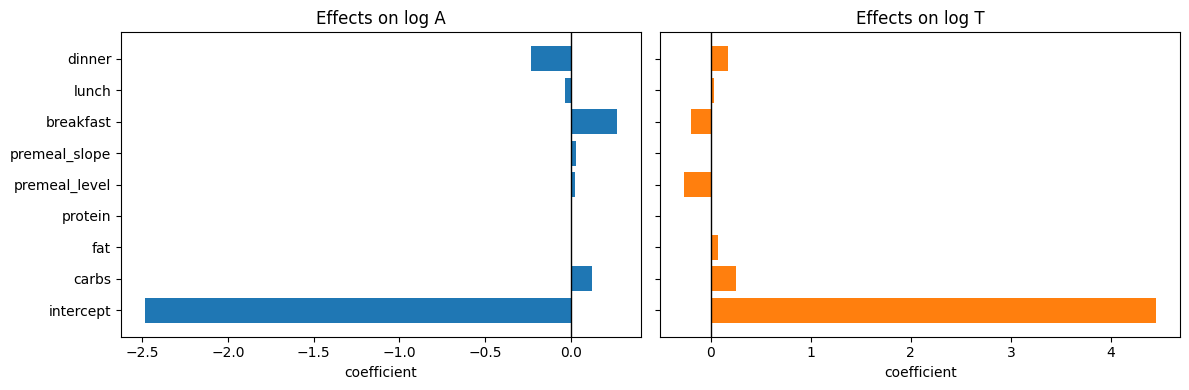

,check,value,passed
0,carbs effect on A is non-negative,0.124875,True
1,fat direct effect on A is non-negative,0.000000,True
2,protein direct effect on A is fixed at zero,0.000000,True
3,fat effect on T is non-negative,0.072969,True
4,protein effect on T is non-negative,0.000000,True


In [ ]:
# =========================================================
# PRIOR MODEL DIAGNOSTICS: FEATURE EFFECTS AND BIOLOGICAL CHECKS
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].barh(prior_feature_effects["feature"], prior_feature_effects["log_A_used"])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Effects on log A")
axes[0].set_xlabel("coefficient")

axes[1].barh(prior_feature_effects["feature"], prior_feature_effects["log_T_used"], color="tab:orange")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Effects on log T")
axes[1].set_xlabel("coefficient")

plt.tight_layout()
plt.show()

prior_constraint_checks


100%|██████████| 475/475 [02:51<00:00,  2.76it/s]


Chronological diagnostic: this is meal order, not a randomized learning curve. Run the next cell for the random-split test.


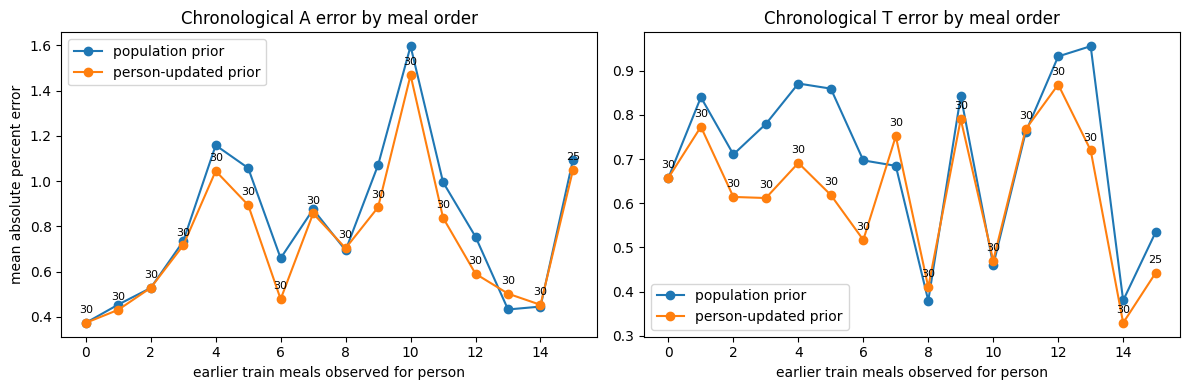

,prior_meals_capped,n_meals,n_people,A_base_pct_error,A_personalized_pct_error,T_base_pct_error,T_personalized_pct_error,A_base_abs_log_error,A_personalized_abs_log_error,T_base_abs_log_error,T_personalized_abs_log_error,A_pct_error_improvement,T_pct_error_improvement
0,0,30,30,0.373263,0.373263,0.657669,0.657669,0.361774,0.361774,0.569840,0.569840,0.000000,0.000000
1,1,30,30,0.454195,0.431086,0.839877,0.773060,0.521490,0.497504,0.646584,0.602187,0.023110,0.066818
2,2,30,30,0.527739,0.528359,0.710547,0.614332,0.533358,0.504896,0.629558,0.553938,-0.000620,0.096215
3,3,30,30,0.733871,0.715820,0.779456,0.611890,0.589411,0.543603,0.620650,0.501066,0.018051,0.167566
4,4,30,30,1.158454,1.044708,0.870932,0.691268,0.727527,0.633895,0.609846,0.512901,0.113746,0.179665
5,5,30,30,1.057844,0.894352,0.859327,0.618775,0.714351,0.578465,0.678142,0.521992,0.163492,0.240552
6,6,30,30,0.659104,0.478065,0.697035,0.517090,0.585812,0.432270,0.619359,0.515088,0.181039,0.179945
7,7,30,30,0.875073,0.857073,0.684702,0.751732,0.623068,0.642481,0.474336,0.525123,0.018001,-0.067030
8,8,30,30,0.694070,0.703377,0.379633,0.410153,0.540627,0.508573,0.361844,0.396060,-0.009307,-0.030519
9,9,30,30,1.071191,0.884482,0.843033,0.790198,0.684553,0.581750,0.547621,0.560086,0.186709,0.052835


In [ ]:
# =========================================================
# DOES PERSONALIZATION IMPROVE AS EACH PERSON HAS MORE MEALS?
# =========================================================

# The main prior-label set is balanced across many people, so with ~100 people it
# may only contain 1-2 meals per person. For a real learning curve, we build a
# focused repeated-meal label set for people with many training meals.

MAX_LEARNING_CURVE_PEOPLE = 30
MAX_LEARNING_CURVE_MEALS_PER_PERSON = 20
MAX_LEARNING_CURVE_TOTAL_LABEL_MEALS = 600
MAX_LEARNING_CURVE_PRIOR_MEALS_SHOWN = 19
LEARNING_LABEL_A_GRID_SIZE = 12
LEARNING_LABEL_T_GRID_SIZE = 12


def select_repeated_person_indices(
    ds,
    indices,
    max_people=MAX_LEARNING_CURVE_PEOPLE,
    max_meals_per_person=MAX_LEARNING_CURVE_MEALS_PER_PERSON,
    max_total_meals=MAX_LEARNING_CURVE_TOTAL_LABEL_MEALS,
):
    by_person = defaultdict(list)
    for idx in indices:
        by_person[int(ds.meals[idx]["person_id"])].append(int(idx))

    for person_id in by_person:
        by_person[person_id] = sorted(by_person[person_id])

    ranked_people = sorted(by_person, key=lambda p: (-len(by_person[p]), p))[:max_people]
    selected = []
    for meal_rank in range(max_meals_per_person):
        for person_id in ranked_people:
            if meal_rank >= len(by_person[person_id]):
                continue
            selected.append(by_person[person_id][meal_rank])
            if len(selected) >= max_total_meals:
                return selected

    return selected


def build_learning_curve_label_rows(ds, indices):
    existing = {int(row["idx"]): row for row in at_label_rows}
    rows = []
    extra_indices = select_repeated_person_indices(
        ds,
        indices,
        max_people=MAX_LEARNING_CURVE_PEOPLE,
        max_meals_per_person=MAX_LEARNING_CURVE_MEALS_PER_PERSON,
        max_total_meals=MAX_LEARNING_CURVE_TOTAL_LABEL_MEALS,
    )

    learning_A_grid = np.linspace(0.01, 0.30, LEARNING_LABEL_A_GRID_SIZE)
    learning_T_grid = np.linspace(15.0, 165.0, LEARNING_LABEL_T_GRID_SIZE)

    for idx in tqdm(extra_indices):
        idx = int(idx)
        if idx in existing:
            rows.append(existing[idx])
            continue

        sample = sample_from_dataset(ds, idx)
        label = infer_completed_meal_at_posterior(
            sample,
            A_grid=learning_A_grid,
            T_grid=learning_T_grid,
        )
        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            **label,
            "features": meal_feature_vector(sample),
        })

    return rows


def estimate_person_learning_curve(rows, prior_strength=PERSON_OFFSET_PRIOR_STRENGTH):
    by_person = defaultdict(list)
    for row in rows:
        by_person[int(row["person_id"])].append(row)

    learning_rows = []

    for person_id, person_rows in by_person.items():
        person_rows = sorted(person_rows, key=lambda r: int(r["idx"]))
        prior_A_residuals = []
        prior_T_residuals = []

        for row_number, row in enumerate(person_rows):
            x = np.asarray(row["features"], dtype=float)
            true_log_A = np.log(max(float(row["A_mean"]), PARAM_BOUNDS["A"][0]))
            true_log_T = np.log(np.clip(float(row["T_mean"]), *PARAM_BOUNDS["T"]))

            base_log_A = predict_from_ridge(x, coef_log_A)
            base_log_T = predict_from_ridge(x, coef_log_T)

            n_prior = len(prior_A_residuals)
            offset_A = float(np.sum(prior_A_residuals) / (n_prior + prior_strength)) if n_prior else 0.0
            offset_T = float(np.sum(prior_T_residuals) / (n_prior + prior_strength)) if n_prior else 0.0

            personalized_log_A = base_log_A + offset_A
            personalized_log_T = base_log_T + offset_T

            base_A = float(np.clip(np.exp(base_log_A), *PARAM_BOUNDS["A"]))
            base_T = float(np.clip(np.exp(base_log_T), *PARAM_BOUNDS["T"]))
            personalized_A = float(np.clip(np.exp(personalized_log_A), *PARAM_BOUNDS["A"]))
            personalized_T = float(np.clip(np.exp(personalized_log_T), *PARAM_BOUNDS["T"]))

            learning_rows.append({
                "person_id": person_id,
                "idx": row["idx"],
                "meal_number": row_number + 1,
                "prior_meals": n_prior,
                "prior_meals_capped": min(n_prior, MAX_LEARNING_CURVE_PRIOR_MEALS_SHOWN),
                "A_true": float(row["A_mean"]),
                "T_true": float(row["T_mean"]),
                "A_base_pred": base_A,
                "T_base_pred": base_T,
                "A_personalized_pred": personalized_A,
                "T_personalized_pred": personalized_T,
                "A_base_abs_log_error": abs(base_log_A - true_log_A),
                "T_base_abs_log_error": abs(base_log_T - true_log_T),
                "A_personalized_abs_log_error": abs(personalized_log_A - true_log_A),
                "T_personalized_abs_log_error": abs(personalized_log_T - true_log_T),
                "A_base_pct_error": abs(base_A - float(row["A_mean"])) / max(float(row["A_mean"]), 1e-6),
                "T_base_pct_error": abs(base_T - float(row["T_mean"])) / max(float(row["T_mean"]), 1e-6),
                "A_personalized_pct_error": abs(personalized_A - float(row["A_mean"])) / max(float(row["A_mean"]), 1e-6),
                "T_personalized_pct_error": abs(personalized_T - float(row["T_mean"])) / max(float(row["T_mean"]), 1e-6),
            })

            prior_A_residuals.append(true_log_A - base_log_A)
            prior_T_residuals.append(true_log_T - base_log_T)

    return pd.DataFrame(learning_rows)


learning_curve_label_rows = build_learning_curve_label_rows(mode2_dataset, train_idx)
person_learning_df = estimate_person_learning_curve(learning_curve_label_rows)
learning_summary = person_learning_df.groupby("prior_meals_capped").agg(
    n_meals=("idx", "count"),
    n_people=("person_id", "nunique"),
    A_base_pct_error=("A_base_pct_error", "mean"),
    A_personalized_pct_error=("A_personalized_pct_error", "mean"),
    T_base_pct_error=("T_base_pct_error", "mean"),
    T_personalized_pct_error=("T_personalized_pct_error", "mean"),
    A_base_abs_log_error=("A_base_abs_log_error", "mean"),
    A_personalized_abs_log_error=("A_personalized_abs_log_error", "mean"),
    T_base_abs_log_error=("T_base_abs_log_error", "mean"),
    T_personalized_abs_log_error=("T_personalized_abs_log_error", "mean"),
).reset_index()

learning_summary["A_pct_error_improvement"] = (
    learning_summary["A_base_pct_error"] - learning_summary["A_personalized_pct_error"]
)
learning_summary["T_pct_error_improvement"] = (
    learning_summary["T_base_pct_error"] - learning_summary["T_personalized_pct_error"]
)

print("Chronological diagnostic: this is meal order, not a randomized learning curve. Run the next cell for the random-split test.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(learning_summary["prior_meals_capped"], learning_summary["A_base_pct_error"], marker="o", label="population prior")
axes[0].plot(learning_summary["prior_meals_capped"], learning_summary["A_personalized_pct_error"], marker="o", label="person-updated prior")
axes[0].set_title("Chronological A error by meal order")
axes[0].set_xlabel("earlier train meals observed for person")
axes[0].set_ylabel("mean absolute percent error")
axes[0].legend()
for _, row in learning_summary.iterrows():
    axes[0].annotate(
        int(row["n_meals"]),
        (row["prior_meals_capped"], row["A_personalized_pct_error"]),
        textcoords="offset points",
        xytext=(0, 7),
        ha="center",
        fontsize=8,
    )

axes[1].plot(learning_summary["prior_meals_capped"], learning_summary["T_base_pct_error"], marker="o", label="population prior")
axes[1].plot(learning_summary["prior_meals_capped"], learning_summary["T_personalized_pct_error"], marker="o", label="person-updated prior")
axes[1].set_title("Chronological T error by meal order")
axes[1].set_xlabel("earlier train meals observed for person")
axes[1].legend()
for _, row in learning_summary.iterrows():
    axes[1].annotate(
        int(row["n_meals"]),
        (row["prior_meals_capped"], row["T_personalized_pct_error"]),
        textcoords="offset points",
        xytext=(0, 7),
        ha="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

learning_summary


In [ ]:
# =========================================================
# RANDOM-SPLIT PERSONALIZATION LEARNING CURVE
# =========================================================

# The chronological curve above can be noisy because the 10th meal for a person
# may simply be a harder meal. This version asks a cleaner question:
# if we randomly give the model k prior meals from a person, does it predict
# that person's held-out meals better?

RANDOM_LEARNING_K_VALUES = [0, 1, 2, 4, 8, 12, 16]
RANDOM_LEARNING_REPEATS = 40
RANDOM_LEARNING_MAX_EVAL_MEALS_PER_PERSON = 5
RANDOM_LEARNING_SEED = 123


def log_at_targets(row):
    true_log_A = np.log(max(float(row["A_mean"]), PARAM_BOUNDS["A"][0]))
    true_log_T = np.log(np.clip(float(row["T_mean"]), *PARAM_BOUNDS["T"]))
    return true_log_A, true_log_T


def base_log_at_prediction(row):
    x = np.asarray(row["features"], dtype=float)
    return predict_from_ridge(x, coef_log_A), predict_from_ridge(x, coef_log_T)


def at_prediction_error_row(row, adjustment_A=0.0, adjustment_T=0.0):
    true_log_A, true_log_T = log_at_targets(row)
    base_log_A, base_log_T = base_log_at_prediction(row)
    personalized_log_A = base_log_A + adjustment_A
    personalized_log_T = base_log_T + adjustment_T

    base_A = float(np.clip(np.exp(base_log_A), *PARAM_BOUNDS["A"]))
    base_T = float(np.clip(np.exp(base_log_T), *PARAM_BOUNDS["T"]))
    personalized_A = float(np.clip(np.exp(personalized_log_A), *PARAM_BOUNDS["A"]))
    personalized_T = float(np.clip(np.exp(personalized_log_T), *PARAM_BOUNDS["T"]))
    true_A = float(row["A_mean"])
    true_T = float(row["T_mean"])

    return {
        "A_base_pct_error": abs(base_A - true_A) / max(true_A, 1e-6),
        "A_personalized_pct_error": abs(personalized_A - true_A) / max(true_A, 1e-6),
        "T_base_pct_error": abs(base_T - true_T) / max(true_T, 1e-6),
        "T_personalized_pct_error": abs(personalized_T - true_T) / max(true_T, 1e-6),
        "A_base_abs_log_error": abs(base_log_A - true_log_A),
        "A_personalized_abs_log_error": abs(personalized_log_A - true_log_A),
        "T_base_abs_log_error": abs(base_log_T - true_log_T),
        "T_personalized_abs_log_error": abs(personalized_log_T - true_log_T),
    }


def person_adjustments_from_prior_rows(prior_rows):
    if not prior_rows:
        return {}, {}, {}, {}

    residual_A = []
    residual_T = []
    weights = []
    for row in prior_rows:
        true_log_A, true_log_T = log_at_targets(row)
        base_log_A, base_log_T = base_log_at_prediction(row)
        residual_A.append(true_log_A - base_log_A)
        residual_T.append(true_log_T - base_log_T)
        weights.append(label_reliability_weight(row))

    offsets_A = fit_person_offsets(
        prior_rows,
        residual_A,
        weights=weights,
        prior_strength=PERSON_OFFSET_PRIOR_STRENGTH,
    )
    offsets_T = fit_person_offsets(
        prior_rows,
        residual_T,
        weights=weights,
        prior_strength=PERSON_OFFSET_PRIOR_STRENGTH,
    )
    slopes_A = fit_person_slopes(
        prior_rows,
        residual_A,
        PERSON_A_SLOPE_FEATURE_IDX,
        offsets=offsets_A,
        weights=weights,
        prior_strength=PERSON_SLOPE_PRIOR_STRENGTH,
    )
    slopes_T = fit_person_slopes(
        prior_rows,
        residual_T,
        PERSON_T_SLOPE_FEATURE_IDX,
        offsets=offsets_T,
        weights=weights,
        prior_strength=PERSON_SLOPE_PRIOR_STRENGTH,
    )
    return offsets_A, offsets_T, slopes_A, slopes_T


def estimate_random_split_learning_curve(
    rows,
    k_values=RANDOM_LEARNING_K_VALUES,
    repeats=RANDOM_LEARNING_REPEATS,
    max_eval_meals_per_person=RANDOM_LEARNING_MAX_EVAL_MEALS_PER_PERSON,
    seed=RANDOM_LEARNING_SEED,
):
    by_person = defaultdict(list)
    for row in rows:
        by_person[int(row["person_id"])].append(row)

    for person_id in by_person:
        by_person[person_id] = sorted(by_person[person_id], key=lambda r: int(r["idx"]))

    result_rows = []
    for k in k_values:
        for repeat in range(repeats):
            rng = np.random.default_rng(seed + 1009 * repeat + 37 * k)
            for person_id, person_rows in by_person.items():
                if len(person_rows) <= k:
                    continue

                order = rng.permutation(len(person_rows))
                prior_rows = [person_rows[int(j)] for j in order[:k]]
                eval_rows = [person_rows[int(j)] for j in order[k:]]
                eval_rows = eval_rows[:max_eval_meals_per_person]

                if not eval_rows:
                    continue

                offsets_A, offsets_T, slopes_A, slopes_T = person_adjustments_from_prior_rows(prior_rows)

                for row in eval_rows:
                    adjustment_A = person_linear_adjustment(
                        row,
                        offsets_A,
                        slopes_A,
                        PERSON_A_SLOPE_FEATURE_IDX,
                    )
                    adjustment_T = person_linear_adjustment(
                        row,
                        offsets_T,
                        slopes_T,
                        PERSON_T_SLOPE_FEATURE_IDX,
                    )
                    result_rows.append({
                        "prior_meals": k,
                        "repeat": repeat,
                        "person_id": person_id,
                        "idx": int(row["idx"]),
                        **at_prediction_error_row(row, adjustment_A=adjustment_A, adjustment_T=adjustment_T),
                    })

    return pd.DataFrame(result_rows)


random_learning_df = estimate_random_split_learning_curve(learning_curve_label_rows)

RANDOM_LEARNING_METRICS = [
    "A_base_pct_error",
    "A_personalized_pct_error",
    "T_base_pct_error",
    "T_personalized_pct_error",
    "A_base_abs_log_error",
    "A_personalized_abs_log_error",
    "T_base_abs_log_error",
    "T_personalized_abs_log_error",
]

random_learning_repeat_summary = random_learning_df.groupby(["prior_meals", "repeat"]).agg(
    n_eval=("idx", "count"),
    **{metric: (metric, "mean") for metric in RANDOM_LEARNING_METRICS},
).reset_index()

random_learning_summary = random_learning_repeat_summary.groupby("prior_meals").agg(
    n_repeats=("repeat", "count"),
    n_eval_mean=("n_eval", "mean"),
    **{metric: (metric, "mean") for metric in RANDOM_LEARNING_METRICS},
).reset_index()

random_learning_counts = random_learning_df.groupby("prior_meals").agg(
    n_eval_total=("idx", "count"),
    n_people=("person_id", "nunique"),
).reset_index()
random_learning_summary = random_learning_summary.merge(random_learning_counts, on="prior_meals", how="left")

for metric in RANDOM_LEARNING_METRICS:
    metric_sd = random_learning_repeat_summary.groupby("prior_meals")[metric].std(ddof=1)
    n_repeats = random_learning_summary.set_index("prior_meals")["n_repeats"]
    ci95 = 1.96 * metric_sd / np.sqrt(n_repeats)
    random_learning_summary[f"{metric}_ci95"] = random_learning_summary["prior_meals"].map(ci95).fillna(0.0).to_numpy()

random_learning_summary["A_pct_error_improvement"] = (
    random_learning_summary["A_base_pct_error"] - random_learning_summary["A_personalized_pct_error"]
)
random_learning_summary["T_pct_error_improvement"] = (
    random_learning_summary["T_base_pct_error"] - random_learning_summary["T_personalized_pct_error"]
)

print("Random-split diagnostic: this is the cleaner test of whether more prior meals improve personalization.")
print("Point labels show unique people at each k. Confidence bands are 95% intervals across random repeats.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)


def plot_random_learning_metric(ax, base_col, personal_col, title):
    x = random_learning_summary["prior_meals"].to_numpy(dtype=float)
    base = random_learning_summary[base_col].to_numpy(dtype=float)
    personal = random_learning_summary[personal_col].to_numpy(dtype=float)
    base_ci = random_learning_summary[f"{base_col}_ci95"].to_numpy(dtype=float)
    personal_ci = random_learning_summary[f"{personal_col}_ci95"].to_numpy(dtype=float)

    ax.plot(x, base, marker="o", label="population prior")
    ax.fill_between(x, base - base_ci, base + base_ci, alpha=0.12)
    ax.plot(x, personal, marker="o", label="person-updated prior")
    ax.fill_between(x, personal - personal_ci, personal + personal_ci, alpha=0.12)
    ax.set_title(title)
    ax.set_xlabel("random prior meals used per person")
    ax.legend()

    for _, row in random_learning_summary.iterrows():
        ax.annotate(
            f"p={int(row['n_people'])}",
            (row["prior_meals"], row[personal_col]),
            textcoords="offset points",
            xytext=(0, 7),
            ha="center",
            fontsize=8,
        )


plot_random_learning_metric(
    axes[0],
    "A_base_pct_error",
    "A_personalized_pct_error",
    "Random-split A prediction error",
)
axes[0].set_ylabel("mean absolute percent error")

plot_random_learning_metric(
    axes[1],
    "T_base_pct_error",
    "T_personalized_pct_error",
    "Random-split T prediction error",
)

plt.tight_layout()
plt.show()

random_learning_summary


In [ ]:
# =========================================================
# PERSON-SPECIFIC ACKERMAN KINETICS FROM COMPLETED-MEAL LABELS
# =========================================================

from scipy.optimize import minimize

KINETIC_BOUNDS = {
    "period": (80.0, 280.0),
    "zeta": (0.25, 1.75),
}

# These settings control the number of completed meals used to estimate each
# person's transition kinetics. This is separate from MAX_PRIOR_TRAIN_MEALS:
# the prior model can be trained on a balanced sample, while kinetics needs
# multiple meals from the same person.
MAX_KINETIC_PEOPLE = 40
MAX_KINETIC_MEALS_PER_PERSON = 20
MIN_KINETIC_MEALS_PER_PERSON = 5
MAX_KINETIC_TOTAL_LABEL_MEALS = 800
MAX_KINETIC_POPULATION_LABEL_MEALS = 250
KINETIC_PERSON_PRIOR_WEIGHT = 120.0
KINETIC_POP_PRIOR_WEIGHT = 20.0


def spaced_subset(values, max_count):
    values = list(values)
    if len(values) <= max_count:
        return values

    positions = np.linspace(0, len(values) - 1, max_count)
    positions = np.unique(np.round(positions).astype(int))
    return [values[int(pos)] for pos in positions]


def select_kinetic_indices_by_person(
    ds,
    indices,
    max_people=MAX_KINETIC_PEOPLE,
    max_meals_per_person=MAX_KINETIC_MEALS_PER_PERSON,
    max_total_meals=MAX_KINETIC_TOTAL_LABEL_MEALS,
):
    by_person = defaultdict(list)
    for idx in indices:
        person_id = int(ds.meals[idx]["person_id"])
        by_person[person_id].append(int(idx))

    for person_id in by_person:
        by_person[person_id] = sorted(by_person[person_id])

    # Prefer people with enough repeated meals, since transition kinetics are
    # weakly identified from one-off meals.
    person_ids = sorted(by_person, key=lambda p: (-len(by_person[p]), p))[:max_people]

    candidate_by_person = {
        person_id: spaced_subset(by_person[person_id], max_meals_per_person)
        for person_id in person_ids
    }

    selected_by_person = {person_id: [] for person_id in person_ids}
    selected_flat = []
    for meal_rank in range(max_meals_per_person):
        for person_id in person_ids:
            person_indices = candidate_by_person[person_id]
            if meal_rank >= len(person_indices):
                continue
            idx = person_indices[meal_rank]
            selected_by_person[person_id].append(idx)
            selected_flat.append(idx)
            if len(selected_flat) >= max_total_meals:
                return selected_by_person, selected_flat

    return selected_by_person, selected_flat


def build_kinetic_label_rows(ds, indices, cached_rows):
    selected_by_person, selected_flat = select_kinetic_indices_by_person(ds, indices)
    cached_by_idx = {int(row["idx"]): row for row in cached_rows}
    missing_indices = [idx for idx in selected_flat if idx not in cached_by_idx]

    inferred_by_idx = {}
    for idx in tqdm(missing_indices):
        sample = sample_from_dataset(ds, idx)
        label = infer_completed_meal_at_posterior(
            sample,
            A_grid=LABEL_A_GRID,
            T_grid=LABEL_T_GRID,
        )
        inferred_by_idx[idx] = {
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            **label,
            "features": meal_feature_vector(sample),
        }

    rows = []
    for idx in selected_flat:
        row = cached_by_idx.get(idx, inferred_by_idx.get(idx))
        if row is not None:
            rows.append(dict(row))

    n_available_by_person = defaultdict(int)
    for idx in indices:
        n_available_by_person[int(ds.meals[idx]["person_id"])] += 1

    available_counts = pd.DataFrame({
        "person_id": list(selected_by_person.keys()),
        "n_train_meals_available": [n_available_by_person[person_id] for person_id in selected_by_person],
        "n_kinetic_meals_selected": [len(selected_by_person[person_id]) for person_id in selected_by_person],
    })

    return rows, available_counts


def pack_kinetics(theta):
    return np.log([float(theta["period"]), float(theta["zeta"])])


def unpack_kinetics(params, base_theta=None):
    base = {**ACKERMAN_DEFAULT, **(base_theta or {})}
    values = np.exp(np.asarray(params, dtype=float))
    theta = dict(base)
    theta["period"] = float(np.clip(values[0], *KINETIC_BOUNDS["period"]))
    theta["zeta"] = float(np.clip(values[1], *KINETIC_BOUNDS["zeta"]))
    return theta


def kinetic_prior_penalty(theta, prior_theta):
    period_z = np.log(theta["period"] / prior_theta["period"]) / 0.25
    zeta_z = np.log(theta["zeta"] / prior_theta["zeta"]) / 0.35
    return float(period_z ** 2 + zeta_z ** 2)


def kinetic_loss_for_rows(params, rows, ds, base_theta=None, prior_theta=None, prior_weight=0.0):
    theta = unpack_kinetics(params, base_theta=base_theta)
    losses = []

    for row in rows:
        sample = sample_from_dataset(ds, int(row["idx"]))
        time = sample["time"]
        post = time >= 0
        baseline = float(np.median(sample["glucose"][time < 0])) if np.any(time < 0) else float(sample["glucose"][0])

        trace = rollout_ackerman_pulse(
            sample,
            theta=theta,
            A_meal=float(row["A_mean"]),
            T_meal=float(row["T_mean"]),
        )
        pred = trace["glucose_pred"]
        resid = pred[post] - sample["glucose"][post]

        obs_metrics = response_metrics(time, sample["glucose"], baseline=baseline)
        pred_metrics = response_metrics(time, pred, baseline=baseline)
        post_duration = max(float(time[post][-1] - time[post][0]), 1.0)

        curve_mse = float(np.mean(resid ** 2))
        peak_mse = float((pred_metrics["peak"] - obs_metrics["peak"]) ** 2)
        iauc_mse = float(((pred_metrics["iAUC"] - obs_metrics["iAUC"]) / post_duration) ** 2)
        losses.append(curve_mse + 0.5 * peak_mse + 0.25 * iauc_mse)

    if not losses:
        return 1e9

    loss = float(np.mean(losses))
    if prior_theta is not None and prior_weight > 0:
        loss += prior_weight * kinetic_prior_penalty(theta, prior_theta)
    return loss


def fit_kinetics_for_rows(rows, ds, base_theta=None, prior_theta=None, prior_weight=0.0, maxiter=45):
    base = {**ACKERMAN_DEFAULT, **(base_theta or {})}
    result = minimize(
        lambda params: kinetic_loss_for_rows(
            params,
            rows,
            ds,
            base_theta=base,
            prior_theta=prior_theta,
            prior_weight=prior_weight,
        ),
        x0=pack_kinetics(base),
        bounds=[
            (np.log(KINETIC_BOUNDS["period"][0]), np.log(KINETIC_BOUNDS["period"][1])),
            (np.log(KINETIC_BOUNDS["zeta"][0]), np.log(KINETIC_BOUNDS["zeta"][1])),
        ],
        method="L-BFGS-B",
        options={"maxiter": maxiter},
    )
    return unpack_kinetics(result.x, base_theta=base), result


kinetic_label_rows, kinetic_label_counts = build_kinetic_label_rows(
    mode2_dataset,
    train_idx,
    cached_rows=at_label_rows,
)

kinetic_population_rows = kinetic_label_rows[:min(MAX_KINETIC_POPULATION_LABEL_MEALS, len(kinetic_label_rows))]
population_kinetics_theta, population_kinetics_result = fit_kinetics_for_rows(
    kinetic_population_rows,
    mode2_dataset,
    base_theta=ACKERMAN_DEFAULT,
    prior_theta=ACKERMAN_DEFAULT,
    prior_weight=KINETIC_POP_PRIOR_WEIGHT,
    maxiter=50,
)

rows_by_person = defaultdict(list)
for row in kinetic_label_rows:
    rows_by_person[int(row["person_id"])].append(row)

person_kinetic_rows = []
for person_id in tqdm(sorted(rows_by_person)):
    rows_i = sorted(rows_by_person[person_id], key=lambda r: int(r["idx"]))[:MAX_KINETIC_MEALS_PER_PERSON]

    if len(rows_i) < MIN_KINETIC_MEALS_PER_PERSON:
        theta_i = dict(population_kinetics_theta)
        result_i = None
    else:
        theta_i, result_i = fit_kinetics_for_rows(
            rows_i,
            mode2_dataset,
            base_theta=population_kinetics_theta,
            prior_theta=population_kinetics_theta,
            prior_weight=KINETIC_PERSON_PRIOR_WEIGHT,
            maxiter=40,
        )

    n_available = kinetic_label_counts.loc[
        kinetic_label_counts["person_id"] == int(person_id),
        "n_train_meals_available",
    ]
    n_available = int(n_available.iloc[0]) if len(n_available) else len(rows_i)

    person_kinetic_rows.append({
        "person_id": int(person_id),
        "n_train_meals_available": n_available,
        "n_kinetic_meals": len(rows_i),
        "period": theta_i["period"],
        "zeta": theta_i["zeta"],
        "kinetic_loss": float(result_i.fun) if result_i is not None else np.nan,
        "kinetic_success": bool(result_i.success) if result_i is not None else False,
        "kinetic_population_fallback": result_i is None,
    })

person_kinetics_df = pd.DataFrame(person_kinetic_rows)

print("Kinetic labels:", len(kinetic_label_rows))
print("Population kinetics fit success:", bool(population_kinetics_result.success))
print("Population kinetics:", {"period": population_kinetics_theta["period"], "zeta": population_kinetics_theta["zeta"]})
person_kinetics_df.head()


100%|██████████| 40/40 [01:09<00:00,  1.75s/it]

Kinetic labels: 625
Population kinetics fit success: True
Population kinetics: {'period': 170.50352499121948, 'zeta': 0.6156426571573405}


,person_id,n_train_meals_available,n_kinetic_meals,period,zeta,kinetic_loss,kinetic_success,kinetic_population_fallback
0,2,16,16,171.940070,0.630631,278.316984,True,False
1,8,16,16,169.910672,0.613427,204.820867,True,False
2,9,16,16,177.780043,0.600476,682.404033,True,False
3,10,16,16,174.025557,0.637601,450.389434,True,False
4,14,16,16,169.521780,0.595263,293.795245,True,False


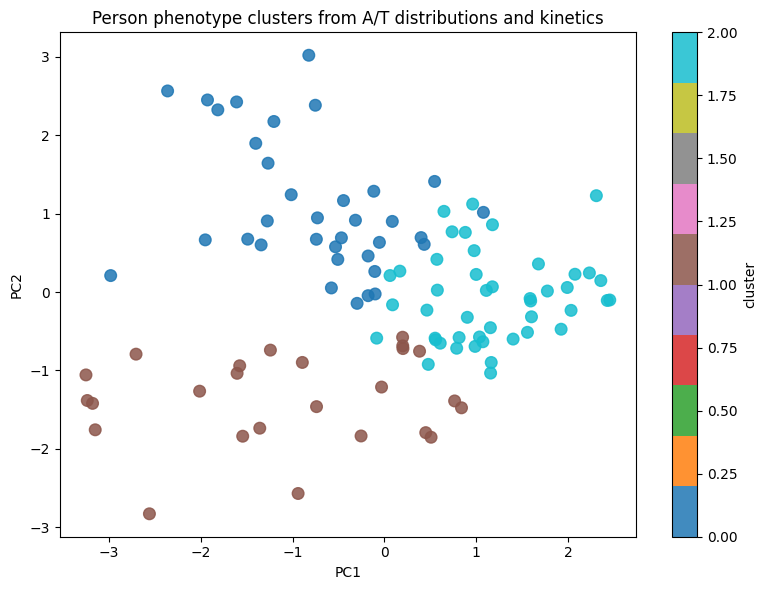

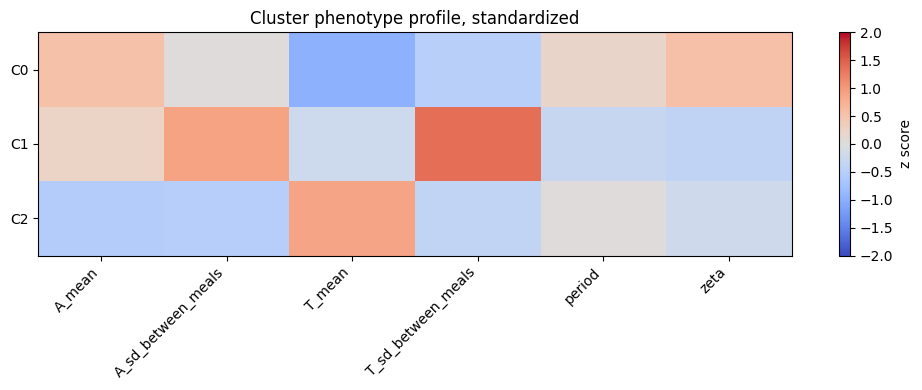

,phenotype_cluster,A_mean,A_sd_between_meals,T_mean,T_sd_between_meals,period,zeta,n_labeled_meals,phenotype_name
0,0,0.125856,0.045051,52.199485,19.767026,171.365750,0.628063,1.885714,"high-A, short-T, slow-kinetics"
1,1,0.111329,0.084600,81.638845,76.727447,170.473591,0.610307,2.000000,"high-A, short-T, fast-kinetics"
2,2,0.073308,0.020837,124.538254,23.932108,171.053166,0.613748,1.866667,"low-A, long-T, slow-kinetics"


In [ ]:
# =========================================================
# PERSON PHENOTYPE TABLE AND CLUSTERING
# =========================================================


def kmeans_numpy(X, n_clusters=4, n_iter=100, random_state=0):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    n_clusters = int(min(max(1, n_clusters), n))

    centers = X[rng.choice(n, size=n_clusters, replace=False)]
    labels = np.zeros(n, dtype=int)

    for _ in range(n_iter):
        distances = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)
        new_labels = np.argmin(distances, axis=1)
        new_centers = centers.copy()

        for k in range(n_clusters):
            members = X[new_labels == k]
            if len(members):
                new_centers[k] = members.mean(axis=0)

        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        centers = new_centers

    return labels, centers


def pca_2d(X):
    X = np.asarray(X, dtype=float)
    X_centered = X - X.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(X_centered, full_matrices=False)
    return X_centered @ vt[:2].T


def build_person_phenotypes(label_rows, kinetics_df=None):
    label_df = pd.DataFrame(label_rows).drop(columns=["features"])
    phenotype = label_df.groupby("person_id").agg(
        n_labeled_meals=("idx", "count"),
        A_mean=("A_mean", "mean"),
        A_sd_between_meals=("A_mean", "std"),
        A_uncertainty=("A_sd", "mean"),
        T_mean=("T_mean", "mean"),
        T_sd_between_meals=("T_mean", "std"),
        T_uncertainty=("T_sd", "mean"),
        posterior_entropy=("posterior_entropy", "mean"),
        label_rmse=("label_rmse", "mean"),
    ).reset_index()

    phenotype["A_sd_between_meals"] = phenotype["A_sd_between_meals"].fillna(0.0)
    phenotype["T_sd_between_meals"] = phenotype["T_sd_between_meals"].fillna(0.0)

    if kinetics_df is not None and len(kinetics_df):
        phenotype = phenotype.merge(
            kinetics_df[["person_id", "period", "zeta", "n_kinetic_meals"]],
            on="person_id",
            how="left",
        )
    else:
        phenotype["period"] = ACKERMAN_DEFAULT["period"]
        phenotype["zeta"] = ACKERMAN_DEFAULT["zeta"]
        phenotype["n_kinetic_meals"] = 0

    phenotype["period"] = phenotype["period"].fillna(population_kinetics_theta["period"] if "population_kinetics_theta" in globals() else ACKERMAN_DEFAULT["period"])
    phenotype["zeta"] = phenotype["zeta"].fillna(population_kinetics_theta["zeta"] if "population_kinetics_theta" in globals() else ACKERMAN_DEFAULT["zeta"])
    phenotype["n_kinetic_meals"] = phenotype["n_kinetic_meals"].fillna(0)
    return phenotype


def cluster_name(row, medians):
    sensitivity = "high-A" if row["A_mean"] >= medians["A_mean"] else "low-A"
    duration = "long-T" if row["T_mean"] >= medians["T_mean"] else "short-T"
    recovery = "slow-kinetics" if row["period"] >= medians["period"] else "fast-kinetics"
    return f"{sensitivity}, {duration}, {recovery}"


person_phenotype_df = build_person_phenotypes(at_label_rows, person_kinetics_df if "person_kinetics_df" in globals() else None)

cluster_features = [
    "A_mean",
    "A_sd_between_meals",
    "T_mean",
    "T_sd_between_meals",
    "period",
    "zeta",
]

X = person_phenotype_df[cluster_features].to_numpy(dtype=float)
X_mean = X.mean(axis=0, keepdims=True)
X_std = X.std(axis=0, keepdims=True)
X_std[X_std == 0] = 1.0
X_z = (X - X_mean) / X_std

N_PHENOTYPE_CLUSTERS = min(3, len(person_phenotype_df))
phenotype_labels, phenotype_centers = kmeans_numpy(X_z, n_clusters=N_PHENOTYPE_CLUSTERS, random_state=1)
phenotype_xy = pca_2d(X_z)

person_phenotype_df["phenotype_cluster"] = phenotype_labels
person_phenotype_df["PC1"] = phenotype_xy[:, 0]
person_phenotype_df["PC2"] = phenotype_xy[:, 1]

medians = person_phenotype_df[cluster_features].median()
cluster_profiles = person_phenotype_df.groupby("phenotype_cluster")[cluster_features + ["n_labeled_meals"]].mean().reset_index()
cluster_profiles["phenotype_name"] = cluster_profiles.apply(lambda row: cluster_name(row, medians), axis=1)
person_phenotype_df = person_phenotype_df.merge(
    cluster_profiles[["phenotype_cluster", "phenotype_name"]],
    on="phenotype_cluster",
    how="left",
)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
scatter = ax.scatter(
    person_phenotype_df["PC1"],
    person_phenotype_df["PC2"],
    c=person_phenotype_df["phenotype_cluster"],
    cmap="tab10",
    s=70,
    alpha=0.85,
)
ax.set_title("Person phenotype clusters from A/T distributions and kinetics")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.colorbar(scatter, ax=ax, label="cluster")
plt.tight_layout()
plt.show()

profile_matrix = cluster_profiles[cluster_features].to_numpy(dtype=float)
profile_z = (profile_matrix - person_phenotype_df[cluster_features].mean().to_numpy()) / person_phenotype_df[cluster_features].std().replace(0, 1).to_numpy()

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
im = ax.imshow(profile_z, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
ax.set_xticks(np.arange(len(cluster_features)))
ax.set_xticklabels(cluster_features, rotation=45, ha="right")
ax.set_yticks(np.arange(len(cluster_profiles)))
ax.set_yticklabels([f"C{int(c)}" for c in cluster_profiles["phenotype_cluster"]])
ax.set_title("Cluster phenotype profile, standardized")
plt.colorbar(im, ax=ax, label="z score")
plt.tight_layout()
plt.show()

cluster_profiles


In [ ]:
# =========================================================
# CLINICAL RISK MARKERS ASSOCIATED WITH PHENOTYPE CLUSTERS
# =========================================================

from scipy.stats import spearmanr, kruskal


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full_like(p_values, np.nan, dtype=float)
    valid = np.isfinite(p_values)
    if not np.any(valid):
        return q_values

    p = p_values[valid]
    order = np.argsort(p)
    ranked = p[order]
    m = len(ranked)
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0.0, 1.0)
    valid_idx = np.where(valid)[0]
    q_values[valid_idx[order]] = adjusted
    return q_values


clinical_feature_path = ROOT_DIR / "data/processed/extracted_features.csv"
clinical_raw = pd.read_csv(clinical_feature_path)

CLINICAL_MARKER_CANDIDATES = [
    "Age",
    "Diabetes duration_years",
    "BMI",
    "WC_cm",
    "HbA1c_perc",
    "HOMA_IR",
    "HOMA2_IR_Cpep",
    "Matsuda",
    "Disposition_index",
    "Fasting glucose_mgdL_x",
    "Fasting insulin_µUmL_x",
    "Cpep_ngmL",
    "Col_LDL_mgdL",
    "Col_HDL_mgdL",
    "TG_mgdL",
    "PAS_mmHg",
    "PAD_mmHg",
]

clinical_marker_cols = [c for c in CLINICAL_MARKER_CANDIDATES if c in clinical_raw.columns]

person_clinical_df = (
    clinical_raw[["ID", "Sex", *clinical_marker_cols]]
    .groupby("ID", as_index=False)
    .agg({
        "Sex": "first",
        **{col: "median" for col in clinical_marker_cols},
    })
    .rename(columns={"ID": "person_id"})
)
person_clinical_df["person_id"] = person_clinical_df["person_id"].astype(int)

phenotype_clinical_df = person_phenotype_df.merge(person_clinical_df, on="person_id", how="left")

clinical_cluster_summary = phenotype_clinical_df.groupby("phenotype_cluster").agg(
    n_people=("person_id", "count"),
    **{f"{col}_median": (col, "median") for col in clinical_marker_cols},
).reset_index()

clinical_means = phenotype_clinical_df.groupby("phenotype_cluster")[clinical_marker_cols].mean()
marker_std = phenotype_clinical_df[clinical_marker_cols].std().replace(0, np.nan)
clinical_z = (clinical_means - phenotype_clinical_df[clinical_marker_cols].mean()) / marker_std
clinical_z = clinical_z.fillna(0.0)

fig, ax = plt.subplots(1, 1, figsize=(12, max(4, 0.45 * len(clinical_marker_cols))))
im = ax.imshow(clinical_z.T, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
ax.set_xticks(np.arange(len(clinical_z.index)))
ax.set_xticklabels([f"C{int(c)}" for c in clinical_z.index])
ax.set_yticks(np.arange(len(clinical_marker_cols)))
ax.set_yticklabels(clinical_marker_cols)
ax.set_title("Clinical marker enrichment by phenotype cluster")
plt.colorbar(im, ax=ax, label="cluster mean z score")
plt.tight_layout()
plt.show()

phenotype_feature_cols = ["A_mean", "A_sd_between_meals", "T_mean", "T_sd_between_meals", "period", "zeta"]
correlation_rows = []
for phenotype_feature in phenotype_feature_cols:
    for marker in clinical_marker_cols:
        pair = phenotype_clinical_df[[phenotype_feature, marker]].dropna()
        if len(pair) < 8:
            continue
        corr, p_value = spearmanr(pair[phenotype_feature], pair[marker])
        correlation_rows.append({
            "phenotype_feature": phenotype_feature,
            "clinical_marker": marker,
            "spearman_corr": float(corr),
            "p_value": float(p_value),
            "n": len(pair),
        })

phenotype_clinical_correlations = pd.DataFrame(correlation_rows)
if len(phenotype_clinical_correlations):
    phenotype_clinical_correlations["q_value"] = benjamini_hochberg(phenotype_clinical_correlations["p_value"])
    phenotype_clinical_correlations = (
        phenotype_clinical_correlations
        .assign(abs_corr=lambda d: d["spearman_corr"].abs())
        .sort_values(["q_value", "abs_corr"], ascending=[True, False])
    )
else:
    phenotype_clinical_correlations = pd.DataFrame(columns=[
        "phenotype_feature",
        "clinical_marker",
        "spearman_corr",
        "p_value",
        "q_value",
        "n",
        "abs_corr",
    ])

cluster_test_rows = []
for marker in clinical_marker_cols:
    groups = [
        group[marker].dropna().to_numpy(dtype=float)
        for _, group in phenotype_clinical_df.groupby("phenotype_cluster")
    ]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) < 2:
        continue
    stat, p_value = kruskal(*groups)
    cluster_test_rows.append({
        "clinical_marker": marker,
        "kruskal_stat": float(stat),
        "p_value": float(p_value),
        "n": int(sum(len(g) for g in groups)),
    })

clinical_cluster_tests = pd.DataFrame(cluster_test_rows)
if len(clinical_cluster_tests):
    clinical_cluster_tests["q_value"] = benjamini_hochberg(clinical_cluster_tests["p_value"])
    clinical_cluster_tests = clinical_cluster_tests.sort_values("q_value")
else:
    clinical_cluster_tests = pd.DataFrame(columns=["clinical_marker", "kruskal_stat", "p_value", "q_value", "n"])

clinical_cluster_summary


In [ ]:
# =========================================================
# ONLINE BAYESIAN POSTERIOR OVER FIXED A/T
# =========================================================


def make_log_grid(center, lower, upper, n=35, factor_low=0.35, factor_high=3.0):
    center = float(np.clip(center, lower, upper))
    lo = max(lower, center * factor_low)
    hi = min(upper, center * factor_high)
    if hi <= lo:
        lo, hi = lower, upper
    return np.exp(np.linspace(np.log(lo), np.log(hi), int(n)))


def make_linear_grid(center, lower, upper, n=35, width=65.0):
    center = float(np.clip(center, lower, upper))
    lo = max(lower, center - width)
    hi = min(upper, center + width)
    if hi <= lo:
        lo, hi = lower, upper
    return np.linspace(lo, hi, int(n))


def make_prediction_grids(prior, n_A=35, n_T=35):
    A_sd = float(prior.get("A_log_sd", 0.65))
    T_sd = float(prior.get("T_log_sd", 0.55))

    A_grid = make_log_grid(
        prior["A"],
        *PARAM_BOUNDS["A"],
        n=n_A,
        factor_low=max(0.12, np.exp(-3.0 * A_sd)),
        factor_high=min(8.0, np.exp(3.0 * A_sd)),
    )

    # Approximate a log-normal 3 SD range on the natural T scale.
    T_width = max(35.0, prior["T"] * (np.exp(2.5 * T_sd) - 1.0))
    T_grid = make_linear_grid(
        prior["T"],
        *PARAM_BOUNDS["T"],
        n=n_T,
        width=T_width,
    )

    return A_grid, T_grid


def build_log_prior(A_grid, T_grid, A_prior=None, T_prior=None, A_log_sd=0.65, T_log_sd=0.55):
    log_prior = np.zeros((len(T_grid), len(A_grid)), dtype=float)

    if A_prior is not None:
        log_A = np.log(np.asarray(A_grid, dtype=float))
        log_A0 = np.log(float(np.clip(A_prior, *PARAM_BOUNDS["A"])))
        log_prior += -0.5 * ((log_A[None, :] - log_A0) / A_log_sd) ** 2

    if T_prior is not None:
        log_T = np.log(np.asarray(T_grid, dtype=float))
        log_T0 = np.log(float(np.clip(T_prior, *PARAM_BOUNDS["T"])))
        log_prior += -0.5 * ((log_T[:, None] - log_T0) / T_log_sd) ** 2

    return log_prior - logsumexp(log_prior)


def online_meal_posterior(
    sample,
    theta,
    A_grid,
    T_grid,
    sigma=12.0,
    A_prior=None,
    T_prior=None,
    A_log_sd=0.65,
    T_log_sd=0.55,
    update_start=0.0,
):
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    A_grid = np.asarray(A_grid, dtype=float)
    T_grid = np.asarray(T_grid, dtype=float)

    trajectory_array = np.empty((len(T_grid), len(A_grid), len(time)), dtype=float)

    for i, T_meal in enumerate(T_grid):
        for j, A_meal in enumerate(A_grid):
            trace = rollout_ackerman_pulse(
                sample,
                theta=theta,
                A_meal=float(A_meal),
                T_meal=float(T_meal),
            )
            trajectory_array[i, j] = trace["glucose_pred"]

    logpost = build_log_prior(
        A_grid,
        T_grid,
        A_prior=A_prior,
        T_prior=T_prior,
        A_log_sd=A_log_sd,
        T_log_sd=T_log_sd,
    )
    posterior_history = []
    logpost_history = []

    for t_idx, t in enumerate(time):
        if t >= update_start:
            resid = glucose[t_idx] - trajectory_array[:, :, t_idx]
            ll = -0.5 * (resid / sigma) ** 2
            logpost = logpost + ll

        logpost = logpost - logsumexp(logpost)
        posterior_history.append(np.exp(logpost).copy())
        logpost_history.append(logpost.copy())

    posterior_history = np.asarray(posterior_history)
    logpost_history = np.asarray(logpost_history)

    A_mean_by_time = np.sum(posterior_history * A_grid[None, None, :], axis=(1, 2))
    T_mean_by_time = np.sum(posterior_history * T_grid[None, :, None], axis=(1, 2))
    A_second = np.sum(posterior_history * (A_grid[None, None, :] ** 2), axis=(1, 2))
    T_second = np.sum(posterior_history * (T_grid[None, :, None] ** 2), axis=(1, 2))

    A_sd_by_time = np.sqrt(np.maximum(A_second - A_mean_by_time ** 2, 0.0))
    T_sd_by_time = np.sqrt(np.maximum(T_second - T_mean_by_time ** 2, 0.0))

    return {
        "time": time,
        "glucose": glucose,
        "A_grid": A_grid,
        "T_grid": T_grid,
        "trajectory_array": trajectory_array,
        "posterior_history": posterior_history,
        "logpost_history": logpost_history,
        "A_mean_by_time": A_mean_by_time,
        "T_mean_by_time": T_mean_by_time,
        "A_sd_by_time": A_sd_by_time,
        "T_sd_by_time": T_sd_by_time,
        "theta": theta,
        "sigma": sigma,
        "A_prior": A_prior,
        "T_prior": T_prior,
        "A_log_sd": A_log_sd,
        "T_log_sd": T_log_sd,
    }


def posterior_predictive_summary(result, posterior_idx=-1, q=(0.05, 0.50, 0.95)):
    posterior = result["posterior_history"][posterior_idx]
    trajectories = result["trajectory_array"]

    pred_mean = np.sum(posterior[:, :, None] * trajectories, axis=(0, 1))

    flat_post = posterior.reshape(-1)
    flat_traj = trajectories.reshape(-1, trajectories.shape[-1])
    pred_q = np.vstack([
        weighted_quantile(flat_traj[:, k], flat_post, q)
        for k in range(flat_traj.shape[1])
    ])

    return {
        "mean": pred_mean,
        "low": pred_q[:, 0],
        "median": pred_q[:, 1],
        "high": pred_q[:, 2],
    }


def posterior_parameter_summary(result, posterior_idx=-1):
    posterior = result["posterior_history"][posterior_idx]
    A_grid = result["A_grid"]
    T_grid = result["T_grid"]

    map_idx = np.unravel_index(np.argmax(posterior), posterior.shape)
    A_mean = float(np.sum(posterior * A_grid[None, :]))
    T_mean = float(np.sum(posterior * T_grid[:, None]))
    A_sd = float(np.sqrt(np.sum(posterior * (A_grid[None, :] - A_mean) ** 2)))
    T_sd = float(np.sqrt(np.sum(posterior * (T_grid[:, None] - T_mean) ** 2)))

    return {
        "A_map": float(A_grid[map_idx[1]]),
        "T_map": float(T_grid[map_idx[0]]),
        "A_mean": A_mean,
        "T_mean": T_mean,
        "A_sd": A_sd,
        "T_sd": T_sd,
    }


def index_nearest(time, value):
    return int(np.argmin(np.abs(np.asarray(time, dtype=float) - float(value))))


def index_last_before(time, value):
    time = np.asarray(time, dtype=float)
    candidates = np.where(time < value)[0]
    if len(candidates) == 0:
        return 0
    return int(candidates[-1])


Person: 1
Meal: 1.0_lunch_3
Meal composition: {'carbs': 73.30000305175781, 'fat': 22.299999237060547, 'protein': 16.5}
Prior A/T: 0.0978, 66.7
Prior log SD A/T: 0.580, 0.567
Premeal posterior mean A/T: 0.1153, 90.1
Final MAP A/T: 0.1330, 61.6
Final mean A/T: 0.1272 +/- 0.0083, 62.5 +/- 3.5


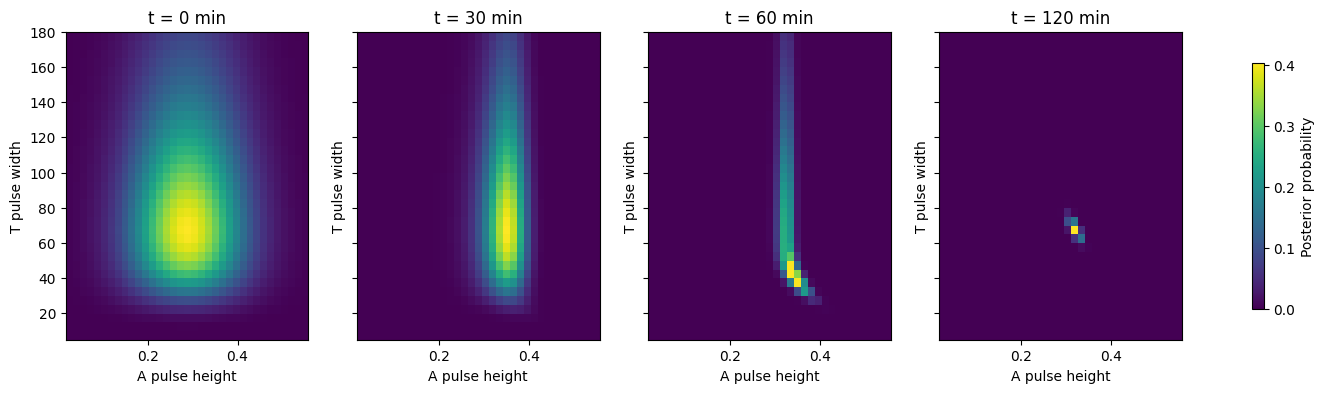

In [ ]:
# =========================================================
# HELD-OUT EXAMPLE: ONLINE POSTERIOR IDENTIFICATION
# =========================================================

example_idx = test_idx[0]
example_sample = sample_from_dataset(mode2_dataset, example_idx)
example_theta = dict(ACKERMAN_DEFAULT)
example_prior = predict_meal_prior_distribution(example_sample)
A_prior = example_prior["A"]
T_prior = example_prior["T"]

A_grid, T_grid = make_prediction_grids(example_prior, n_A=35, n_T=35)

result = online_meal_posterior(
    example_sample,
    example_theta,
    A_grid=A_grid,
    T_grid=T_grid,
    sigma=12.0,
    A_prior=A_prior,
    T_prior=T_prior,
    A_log_sd=example_prior["A_log_sd"],
    T_log_sd=example_prior["T_log_sd"],
    update_start=0.0,
)

final_summary = posterior_parameter_summary(result, posterior_idx=-1)
pre_idx = index_last_before(result["time"], 0.0)
pre_summary = posterior_parameter_summary(result, posterior_idx=pre_idx)

print("Person:", example_sample["person_id"])
print("Meal:", example_sample["meal_id"])
print("Meal composition:", example_sample["meal"])
print(f"Prior A/T: {A_prior:.4f}, {T_prior:.1f}")
print(f"Prior log SD A/T: {example_prior['A_log_sd']:.3f}, {example_prior['T_log_sd']:.3f}")
print(f"Premeal posterior mean A/T: {pre_summary['A_mean']:.4f}, {pre_summary['T_mean']:.1f}")
print(f"Final MAP A/T: {final_summary['A_map']:.4f}, {final_summary['T_map']:.1f}")
print(f"Final mean A/T: {final_summary['A_mean']:.4f} +/- {final_summary['A_sd']:.4f}, {final_summary['T_mean']:.1f} +/- {final_summary['T_sd']:.1f}")

snapshots = [
    index_nearest(result["time"], 0),
    index_nearest(result["time"], 30),
    index_nearest(result["time"], 60),
    index_nearest(result["time"], 120),
]

fig, axes = plt.subplots(1, len(snapshots), figsize=(18, 4), sharey=True)

for ax, idx in zip(axes, snapshots):
    posterior = result["posterior_history"][idx]
    im = ax.imshow(
        posterior,
        origin="lower",
        aspect="auto",
        extent=[A_grid[0], A_grid[-1], T_grid[0], T_grid[-1]],
    )
    ax.set_title(f"t = {result['time'][idx]:.0f} min")
    ax.set_xlabel("A pulse height")
    ax.set_ylabel("T pulse width")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Posterior probability")
plt.show()


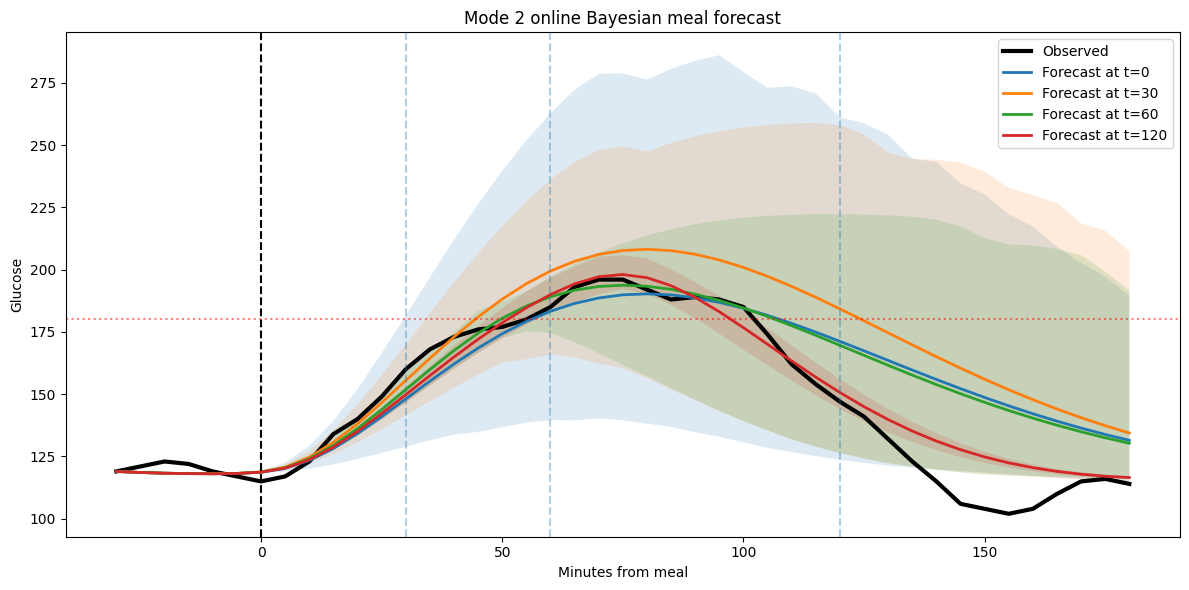

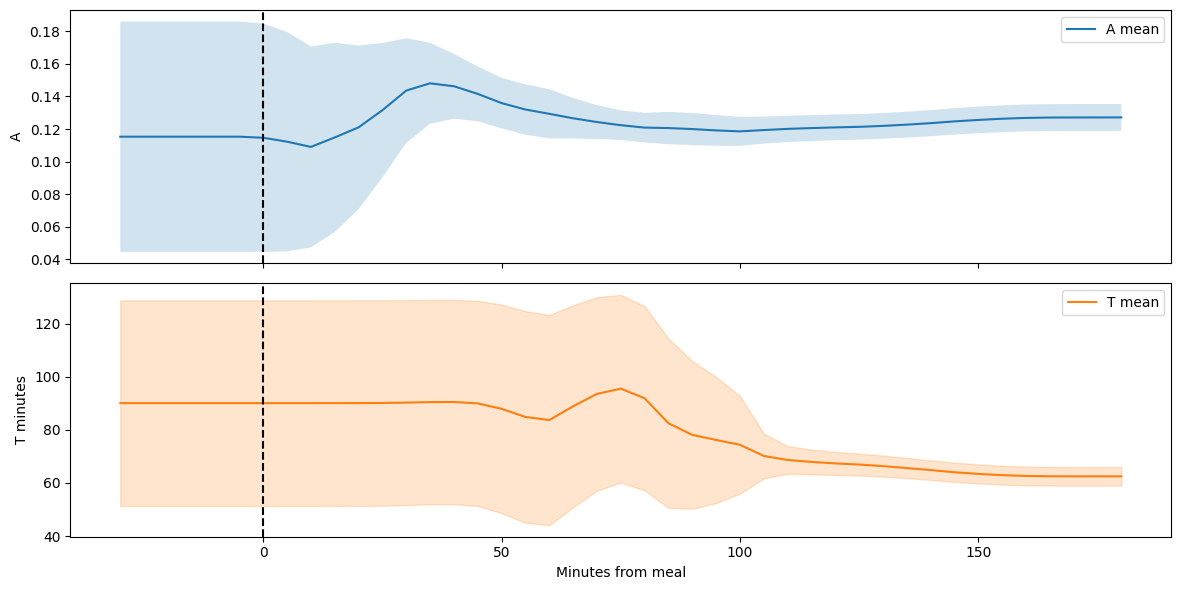

In [ ]:
# =========================================================
# ONLINE FORECAST EVOLUTION
# =========================================================

forecast_times = [0, 30, 60, 120]
forecast_indices = [index_nearest(result["time"], t) for t in forecast_times]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(
    example_sample["time"],
    example_sample["glucose"],
    linewidth=3,
    color="black",
    label="Observed",
)

for idx in forecast_indices:
    pred = posterior_predictive_summary(result, posterior_idx=idx)

    ax.plot(
        result["time"],
        pred["mean"],
        linewidth=2,
        label=f"Forecast at t={result['time'][idx]:.0f}",
    )

    ax.fill_between(
        result["time"],
        pred["low"],
        pred["high"],
        alpha=0.15,
    )

    ax.axvline(result["time"][idx], linestyle="--", alpha=0.35)

ax.axvline(0, color="black", linestyle="--")
ax.axhline(180, color="red", linestyle=":", alpha=0.5)
ax.set_title("Mode 2 online Bayesian meal forecast")
ax.set_xlabel("Minutes from meal")
ax.set_ylabel("Glucose")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(result["time"], result["A_mean_by_time"], label="A mean")
ax[0].fill_between(
    result["time"],
    result["A_mean_by_time"] - result["A_sd_by_time"],
    result["A_mean_by_time"] + result["A_sd_by_time"],
    alpha=0.2,
)
ax[0].axvline(0, color="black", linestyle="--")
ax[0].set_ylabel("A")
ax[0].legend()

ax[1].plot(result["time"], result["T_mean_by_time"], label="T mean", color="tab:orange")
ax[1].fill_between(
    result["time"],
    result["T_mean_by_time"] - result["T_sd_by_time"],
    result["T_mean_by_time"] + result["T_sd_by_time"],
    alpha=0.2,
    color="tab:orange",
)
ax[1].axvline(0, color="black", linestyle="--")
ax[1].set_ylabel("T minutes")
ax[1].set_xlabel("Minutes from meal")
ax[1].legend()
plt.tight_layout()
plt.show()


In [ ]:
# =========================================================
# HELD-OUT EVALUATION
# =========================================================


def evaluate_mode2_heldout(ds, indices, max_meals=50, sigma=12.0):
    rows = []

    for idx in tqdm(indices[:max_meals]):
        sample = sample_from_dataset(ds, idx)
        prior = predict_meal_prior_distribution(sample)
        A_prior = prior["A"]
        T_prior = prior["T"]
        A_grid, T_grid = make_prediction_grids(prior, n_A=25, n_T=25)

        result_i = online_meal_posterior(
            sample,
            ACKERMAN_DEFAULT,
            A_grid=A_grid,
            T_grid=T_grid,
            sigma=sigma,
            A_prior=A_prior,
            T_prior=T_prior,
            A_log_sd=prior["A_log_sd"],
            T_log_sd=prior["T_log_sd"],
            update_start=0.0,
        )

        time = sample["time"]
        post = time >= 0
        baseline = float(np.median(sample["glucose"][time < 0]))
        obs_metrics = response_metrics(time, sample["glucose"], baseline=baseline)

        pre_idx = index_last_before(time, 0.0)
        pre_pred = posterior_predictive_summary(result_i, posterior_idx=pre_idx)["mean"]
        final_pred = posterior_predictive_summary(result_i, posterior_idx=-1)["mean"]
        pre_metrics = response_metrics(time, pre_pred, baseline=baseline)
        final_metrics = response_metrics(time, final_pred, baseline=baseline)
        final_params = posterior_parameter_summary(result_i, posterior_idx=-1)

        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "A_prior": A_prior,
            "T_prior": T_prior,
            "A_log_sd_prior": prior["A_log_sd"],
            "T_log_sd_prior": prior["T_log_sd"],
            **final_params,
            "premeal_forecast_rmse": float(np.sqrt(np.mean((pre_pred[post] - sample["glucose"][post]) ** 2))),
            "final_identified_rmse": float(np.sqrt(np.mean((final_pred[post] - sample["glucose"][post]) ** 2))),
            "premeal_peak_error": pre_metrics["peak"] - obs_metrics["peak"],
            "final_peak_error": final_metrics["peak"] - obs_metrics["peak"],
            "premeal_iAUC_error": pre_metrics["iAUC"] - obs_metrics["iAUC"],
            "final_iAUC_error": final_metrics["iAUC"] - obs_metrics["iAUC"],
        })

    return pd.DataFrame(rows)


MAX_MODE2_HELDOUT_EVAL_MEALS = 50
mode2_eval = evaluate_mode2_heldout(
    mode2_dataset,
    test_idx,
    max_meals=MAX_MODE2_HELDOUT_EVAL_MEALS,
)

mode2_summary = mode2_eval[[
    "premeal_forecast_rmse",
    "final_identified_rmse",
    "premeal_peak_error",
    "final_peak_error",
    "premeal_iAUC_error",
    "final_iAUC_error",
    "A_mean",
    "T_mean",
    "A_sd",
    "T_sd",
]].agg(["count", "mean", "median", "std"])

mode2_summary


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [01:36<00:00,  1.93s/it]


,premeal_forecast_rmse,final_identified_rmse,premeal_peak_error,final_peak_error,premeal_iAUC_error,final_iAUC_error,A_mean,T_mean,A_sd,T_sd
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,23.933948,11.681530,-8.942822,-9.242884,831.207232,-225.318327,0.096614,93.817278,0.007520,8.165679
median,23.465529,10.558644,-9.046999,-8.522494,1401.891377,-179.036922,0.098802,85.902208,0.005935,4.692512
std,9.411881,4.610251,29.671387,8.986598,2770.172124,503.131373,0.046789,37.202454,0.007107,9.712808


In [ ]:
# =========================================================
# UNCERTAINTY CALIBRATION OF PREMEAL AND FINAL POSTERIOR FORECASTS
# =========================================================


def interval_coverage(obs, low, high):
    obs = np.asarray(obs, dtype=float)
    low = np.asarray(low, dtype=float)
    high = np.asarray(high, dtype=float)
    return float(np.mean((obs >= low) & (obs <= high)))


def evaluate_mode2_calibration(ds, indices, max_meals=40, sigma=12.0, n_A=21, n_T=21):
    rows = []

    for idx in tqdm(indices[:max_meals]):
        sample = sample_from_dataset(ds, int(idx))
        prior = predict_meal_prior_distribution(sample)
        A_grid, T_grid = make_prediction_grids(prior, n_A=n_A, n_T=n_T)
        result_i = online_meal_posterior(
            sample,
            ACKERMAN_DEFAULT,
            A_grid=A_grid,
            T_grid=T_grid,
            sigma=sigma,
            A_prior=prior["A"],
            T_prior=prior["T"],
            A_log_sd=prior["A_log_sd"],
            T_log_sd=prior["T_log_sd"],
            update_start=0.0,
        )

        time = sample["time"]
        post = time >= 0
        obs = sample["glucose"]
        baseline = float(np.median(obs[time < 0])) if np.any(time < 0) else float(obs[0])
        obs_metrics = response_metrics(time, obs, baseline=baseline)

        pre_idx = index_last_before(time, 0.0)
        summaries = {
            "premeal": posterior_predictive_summary(result_i, posterior_idx=pre_idx),
            "final": posterior_predictive_summary(result_i, posterior_idx=-1),
        }

        for forecast_stage, pred in summaries.items():
            pred_metrics = response_metrics(time, pred["mean"], baseline=baseline)
            rows.append({
                "idx": int(idx),
                "person_id": sample["person_id"],
                "meal_id": sample["meal_id"],
                "forecast_stage": forecast_stage,
                "pointwise_90_coverage": interval_coverage(obs[post], pred["low"][post], pred["high"][post]),
                "mean_90_width": float(np.mean(pred["high"][post] - pred["low"][post])),
                "rmse": float(np.sqrt(np.mean((pred["mean"][post] - obs[post]) ** 2))),
                "peak_error": pred_metrics["peak"] - obs_metrics["peak"],
                "iAUC_error": pred_metrics["iAUC"] - obs_metrics["iAUC"],
            })

    return pd.DataFrame(rows)


MAX_CALIBRATION_EVAL_MEALS = min(40, MAX_MODE2_HELDOUT_EVAL_MEALS)
mode2_calibration_df = evaluate_mode2_calibration(
    mode2_dataset,
    test_idx,
    max_meals=MAX_CALIBRATION_EVAL_MEALS,
    n_A=21,
    n_T=21,
)

calibration_summary = mode2_calibration_df.groupby("forecast_stage").agg(
    n_meals=("idx", "count"),
    pointwise_90_coverage_mean=("pointwise_90_coverage", "mean"),
    mean_90_width=("mean_90_width", "mean"),
    rmse_mean=("rmse", "mean"),
    peak_error_mean=("peak_error", "mean"),
    iAUC_error_mean=("iAUC_error", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(calibration_summary["forecast_stage"], calibration_summary["pointwise_90_coverage_mean"])
axes[0].axhline(0.90, color="black", linestyle="--", label="nominal 90%")
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Pointwise 90% interval coverage")
axes[0].set_ylabel("coverage")
axes[0].legend()

axes[1].bar(calibration_summary["forecast_stage"], calibration_summary["mean_90_width"], color="tab:orange")
axes[1].set_title("Mean 90% interval width")
axes[1].set_ylabel("mg/dL")

plt.tight_layout()
plt.show()

calibration_summary


In [ ]:
# =========================================================
# PREMEAL COUNTERFACTUAL NUTRITION RECOMMENDATIONS
# =========================================================


def meal_redesign_candidates(meal):
    carbs = float(meal["carbs"])
    fat = float(meal["fat"])
    protein = float(meal["protein"])

    return [
        ("current", {"carbs": carbs, "fat": fat, "protein": protein}),
        ("carbs -20%", {"carbs": 0.80 * carbs, "fat": fat, "protein": protein}),
        ("carbs -40%", {"carbs": 0.60 * carbs, "fat": fat, "protein": protein}),
        ("20g carb -> protein", {"carbs": max(carbs - 20.0, 0.0), "fat": fat, "protein": protein + 20.0}),
        ("10g fat + 10g protein", {"carbs": carbs, "fat": fat + 10.0, "protein": protein + 10.0}),
    ]


def sample_with_meal(sample, meal_override):
    new_sample = dict(sample)
    new_sample["meal"] = dict(meal_override)
    return new_sample


def meal_energy_kcal(meal):
    return 4.0 * float(meal["carbs"]) + 4.0 * float(meal["protein"]) + 9.0 * float(meal["fat"])


def recommendation_realism_penalty(current_meal=None, candidate_meal=None):
    if current_meal is None or candidate_meal is None:
        return 0.0

    current_carbs = max(float(current_meal["carbs"]), 1.0)
    carb_reduction_fraction = max(0.0, float(current_meal["carbs"]) - float(candidate_meal["carbs"])) / current_carbs
    fat_added = max(0.0, float(candidate_meal["fat"]) - float(current_meal["fat"]))
    protein_added = max(0.0, float(candidate_meal["protein"]) - float(current_meal["protein"]))
    energy_change = abs(meal_energy_kcal(candidate_meal) - meal_energy_kcal(current_meal))

    penalty = 0.0
    penalty += 8.0 * max(0.0, carb_reduction_fraction - 0.40)
    penalty += 0.20 * max(0.0, fat_added - 15.0)
    penalty += 0.08 * max(0.0, protein_added - 25.0)
    penalty += 0.015 * max(0.0, energy_change - 120.0)
    return float(penalty)


def counterfactual_uncertainty_penalty(params=None):
    if params is None:
        return 0.0

    A_rel_sd = float(params.get("A_sd", 0.0)) / max(float(params.get("A_mean", 1.0)), 1e-6)
    T_sd = float(params.get("T_sd", 0.0))
    return float(3.0 * A_rel_sd + 0.02 * T_sd)


def score_counterfactual(metrics, current_meal=None, candidate_meal=None, params=None, support_distance=None):
    glucose_score = metrics["peak_delta"] + 0.02 * metrics["iAUC"] + 0.5 * metrics["time_above_180"]
    realism_penalty = recommendation_realism_penalty(current_meal, candidate_meal)
    uncertainty_penalty = counterfactual_uncertainty_penalty(params)
    support_penalty = 0.0 if support_distance is None else 5.0 * max(0.0, float(support_distance) - 0.50)
    return float(glucose_score + realism_penalty + uncertainty_penalty + support_penalty)


def run_premeal_mode2_prediction(sample, theta=None, n_A=25, n_T=25, sigma=12.0):
    prior = predict_meal_prior_distribution(sample)
    A_grid, T_grid = make_prediction_grids(prior, n_A=n_A, n_T=n_T)

    result_cf = online_meal_posterior(
        sample,
        ACKERMAN_DEFAULT if theta is None else theta,
        A_grid=A_grid,
        T_grid=T_grid,
        sigma=sigma,
        A_prior=prior["A"],
        T_prior=prior["T"],
        A_log_sd=prior["A_log_sd"],
        T_log_sd=prior["T_log_sd"],
        update_start=np.inf,
    )

    pred = posterior_predictive_summary(result_cf, posterior_idx=-1)
    params = posterior_parameter_summary(result_cf, posterior_idx=-1)
    return result_cf, pred, params, prior


rows = []
mode2_counterfactual_traces = {}
baseline = float(np.median(example_sample["glucose"][example_sample["time"] < 0]))

for label, candidate_meal in meal_redesign_candidates(example_sample["meal"]):
    candidate_sample = sample_with_meal(example_sample, candidate_meal)
    result_cf, pred, params, prior = run_premeal_mode2_prediction(candidate_sample, theta=example_theta)
    metrics = response_metrics(result_cf["time"], pred["mean"], baseline=baseline)

    realism_penalty = recommendation_realism_penalty(example_sample["meal"], candidate_meal)
    uncertainty_penalty = counterfactual_uncertainty_penalty(params)
    rows.append({
        "candidate": label,
        **candidate_meal,
        "A_prior": prior["A"],
        "T_prior": prior["T"],
        "A_pred_mean": params["A_mean"],
        "T_pred_mean": params["T_mean"],
        "realism_penalty": realism_penalty,
        "uncertainty_penalty": uncertainty_penalty,
        **metrics,
        "score": score_counterfactual(
            metrics,
            current_meal=example_sample["meal"],
            candidate_meal=candidate_meal,
            params=params,
        ),
    })

    mode2_counterfactual_traces[label] = {
        "result": result_cf,
        "prediction": pred,
        "params": params,
        "prior": prior,
    }

mode2_counterfactual_df = pd.DataFrame(rows).sort_values("score")
mode2_counterfactual_df


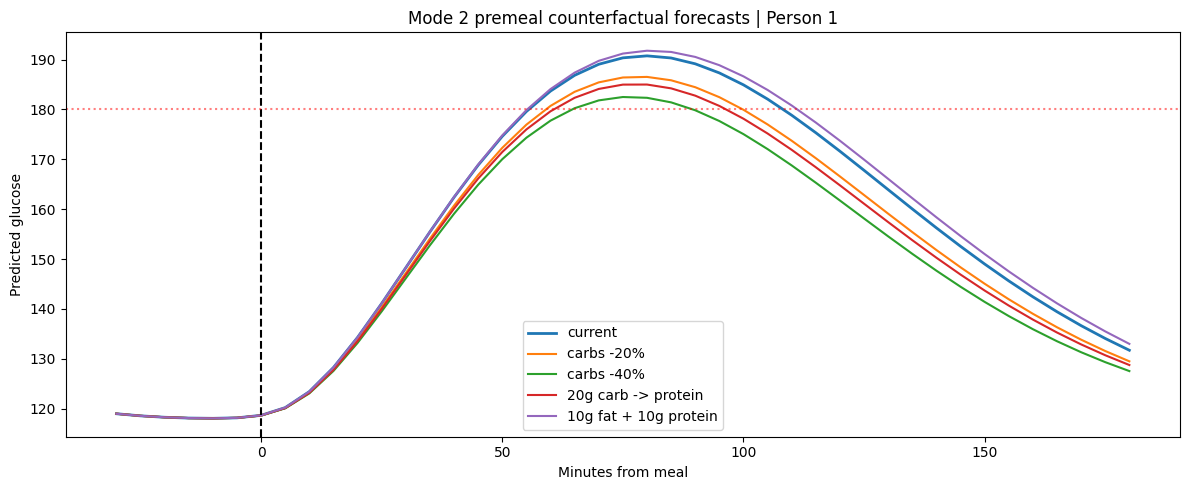

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

for label, item in mode2_counterfactual_traces.items():
    pred = item["prediction"]
    time = item["result"]["time"]
    ax.plot(
        time,
        pred["mean"],
        label=label,
        linewidth=2 if label == "current" else 1.5,
    )

ax.axvline(0, linestyle="--", color="black")
ax.axhline(180, linestyle=":", color="red", alpha=0.5)
ax.set_title(f"Mode 2 premeal counterfactual forecasts | Person {example_sample['person_id']}")
ax.set_ylabel("Predicted glucose")
ax.set_xlabel("Minutes from meal")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# =========================================================
# RECOMMENDATION STABILITY ACROSS HELD-OUT MEALS
# =========================================================


def recommend_for_sample(sample, theta=None, n_A=15, n_T=15):
    baseline = float(np.median(sample["glucose"][sample["time"] < 0]))
    rows = []

    for label, candidate_meal in meal_redesign_candidates(sample["meal"]):
        candidate_sample = sample_with_meal(sample, candidate_meal)
        result_cf, pred, params, prior = run_premeal_mode2_prediction(
            candidate_sample,
            theta=ACKERMAN_DEFAULT if theta is None else theta,
            n_A=n_A,
            n_T=n_T,
        )
        metrics = response_metrics(result_cf["time"], pred["mean"], baseline=baseline)
        realism_penalty = recommendation_realism_penalty(sample["meal"], candidate_meal)
        uncertainty_penalty = counterfactual_uncertainty_penalty(params)
        rows.append({
            "candidate": label,
            **candidate_meal,
            "A_prior": prior["A"],
            "T_prior": prior["T"],
            "A_pred_mean": params["A_mean"],
            "T_pred_mean": params["T_mean"],
            "realism_penalty": realism_penalty,
            "uncertainty_penalty": uncertainty_penalty,
            **metrics,
            "score": score_counterfactual(
                metrics,
                current_meal=sample["meal"],
                candidate_meal=candidate_meal,
                params=params,
            ),
        })

    return pd.DataFrame(rows).sort_values("score")


def evaluate_recommendations(ds, indices, max_meals=25, n_A=15, n_T=15):
    rows = []

    for idx in tqdm(indices[:max_meals]):
        sample = sample_from_dataset(ds, idx)
        rec_df = recommend_for_sample(sample, n_A=n_A, n_T=n_T)
        current = rec_df.loc[rec_df["candidate"] == "current"].iloc[0]
        best = rec_df.iloc[0]

        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "best_candidate": best["candidate"],
            "current_score": current["score"],
            "best_score": best["score"],
            "score_delta": current["score"] - best["score"],
            "current_peak": current["peak"],
            "best_peak": best["peak"],
            "peak_delta": current["peak"] - best["peak"],
            "current_iAUC": current["iAUC"],
            "best_iAUC": best["iAUC"],
            "iAUC_delta": current["iAUC"] - best["iAUC"],
            "best_realism_penalty": best["realism_penalty"],
            "best_uncertainty_penalty": best["uncertainty_penalty"],
            "current_time_above_180": current["time_above_180"],
            "best_time_above_180": best["time_above_180"],
            "time_above_180_delta": current["time_above_180"] - best["time_above_180"],
        })

    return pd.DataFrame(rows)


MAX_RECOMMENDATION_EVAL_MEALS = 25
mode2_recommendation_eval = evaluate_recommendations(
    mode2_dataset,
    test_idx,
    max_meals=MAX_RECOMMENDATION_EVAL_MEALS,
    n_A=15,
    n_T=15,
)

recommendation_summary = mode2_recommendation_eval[[
    "score_delta",
    "peak_delta",
    "iAUC_delta",
    "time_above_180_delta",
]].agg(["count", "mean", "median", "std"])

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
mode2_recommendation_eval["best_candidate"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Best predicted recommendation across held-out meals")
ax.set_ylabel("meal count")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

recommendation_summary


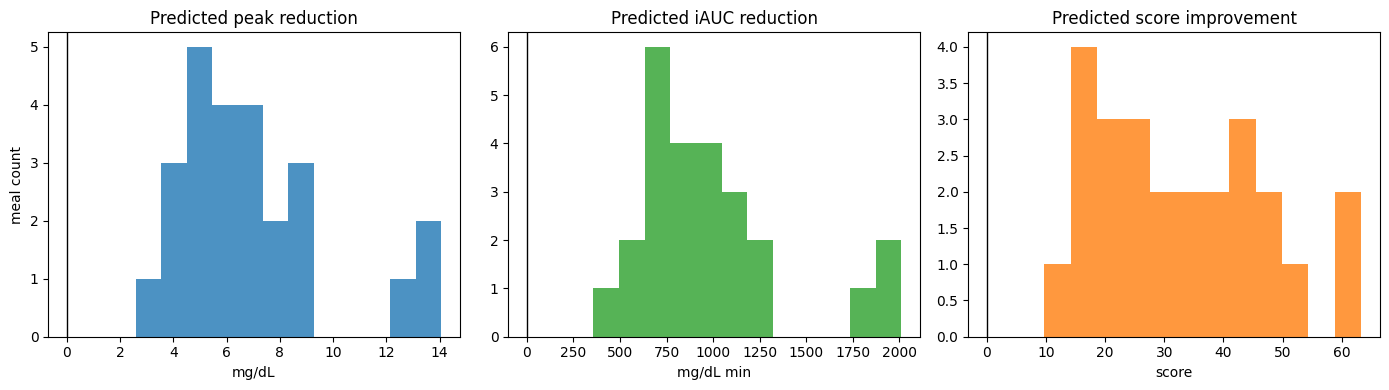

,best_candidate,n_meals,score_delta_mean,peak_delta_mean,iAUC_delta_mean,time_above_180_delta_mean
1,carbs -40%,21,35.846767,7.562707,1057.060110,14.285714
0,20g carb -> protein,4,15.754871,4.134948,580.996138,0.000000


In [ ]:
# =========================================================
# POPULATION RECOMMENDATION STATISTICS
# =========================================================

recommendation_choice_stats = (
    mode2_recommendation_eval["best_candidate"]
    .value_counts()
    .rename_axis("best_candidate")
    .reset_index(name="n_meals")
)
recommendation_choice_stats["fraction"] = recommendation_choice_stats["n_meals"] / recommendation_choice_stats["n_meals"].sum()

recommendation_effect_summary = mode2_recommendation_eval.groupby("best_candidate").agg(
    n_meals=("idx", "count"),
    score_delta_mean=("score_delta", "mean"),
    peak_delta_mean=("peak_delta", "mean"),
    iAUC_delta_mean=("iAUC_delta", "mean"),
    time_above_180_delta_mean=("time_above_180_delta", "mean"),
).reset_index().sort_values("n_meals", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(mode2_recommendation_eval["peak_delta"], bins=12, color="tab:blue", alpha=0.8)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Predicted peak reduction")
axes[0].set_xlabel("mg/dL")
axes[0].set_ylabel("meal count")

axes[1].hist(mode2_recommendation_eval["iAUC_delta"], bins=12, color="tab:green", alpha=0.8)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Predicted iAUC reduction")
axes[1].set_xlabel("mg/dL min")

axes[2].hist(mode2_recommendation_eval["score_delta"], bins=12, color="tab:orange", alpha=0.8)
axes[2].axvline(0, color="black", linewidth=1)
axes[2].set_title("Predicted score improvement")
axes[2].set_xlabel("score")

plt.tight_layout()
plt.show()

recommendation_effect_summary


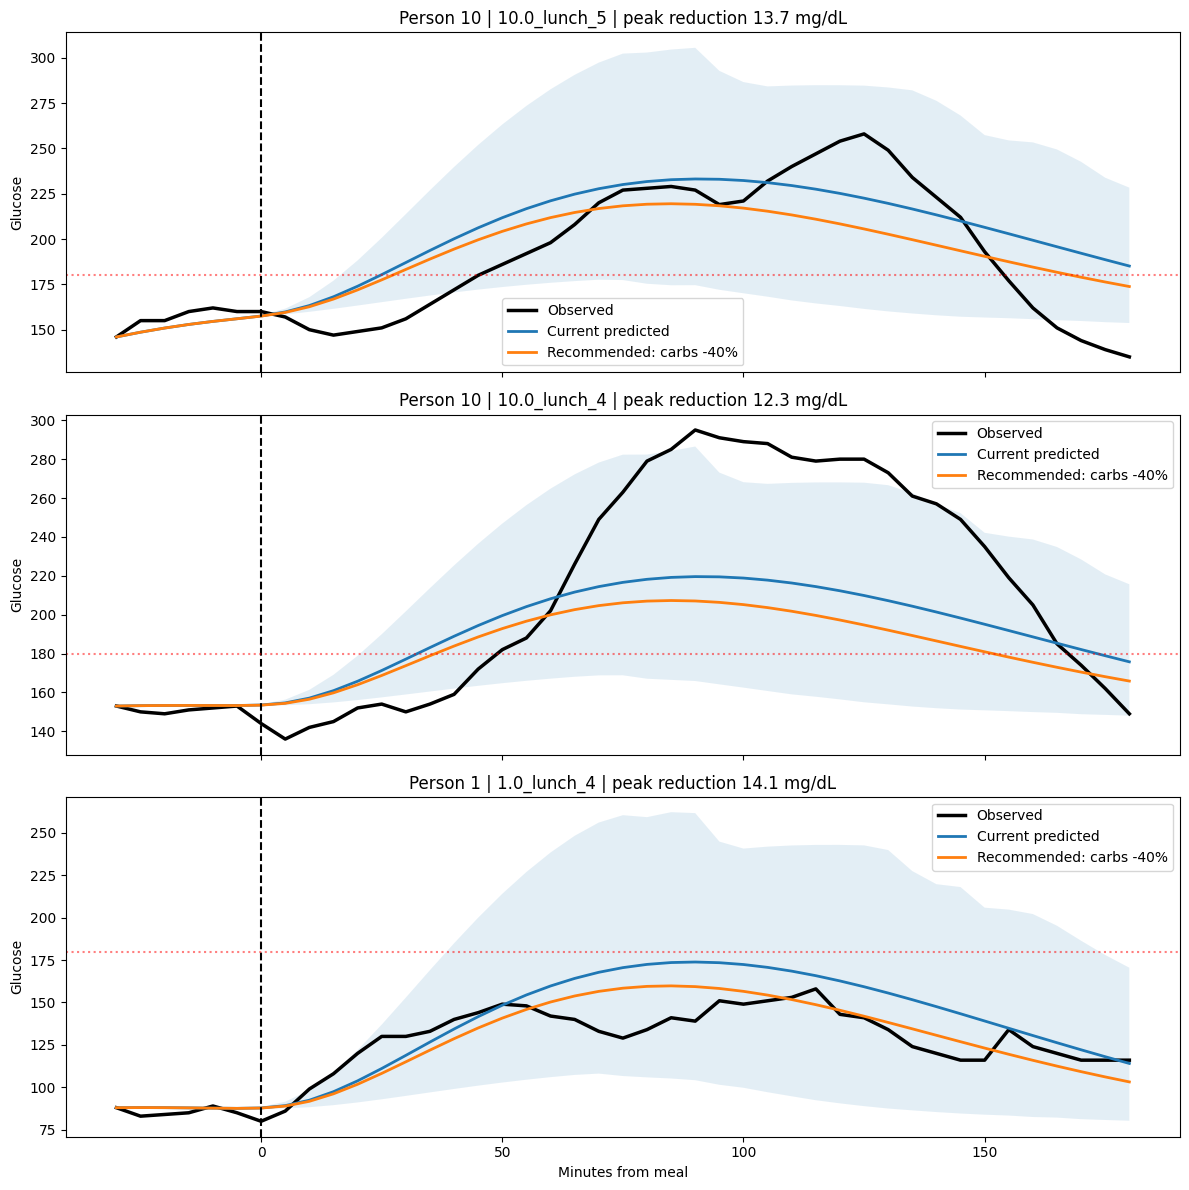

,idx,person_id,meal_id,best_candidate,current_peak,recommended_peak,peak_reduction,current_iAUC,recommended_iAUC,iAUC_reduction
0,36,10,10.0_lunch_5,carbs -40%,233.138521,219.475285,13.663236,9048.713624,7066.121168,1982.592456
1,35,10,10.0_lunch_4,carbs -40%,219.573357,207.276584,12.296773,8084.482528,6319.446402,1765.036126
2,13,1,1.0_lunch_4,carbs -40%,173.837853,159.776910,14.060943,10414.152847,8403.821936,2010.330912


In [ ]:
# =========================================================
# EXAMPLE REAL MEALS WITH CURRENT VS OPTIMAL PREDICTED CHANGE
# =========================================================


def plot_recommendation_examples(ds, recommendation_eval, n_examples=3, n_A=15, n_T=15):
    examples = recommendation_eval.sort_values("score_delta", ascending=False).head(n_examples)
    fig, axes = plt.subplots(len(examples), 1, figsize=(12, 4 * len(examples)), sharex=True)

    if len(examples) == 1:
        axes = [axes]

    example_rows = []

    for ax, (_, rec_row) in zip(axes, examples.iterrows()):
        sample = sample_from_dataset(ds, int(rec_row["idx"]))
        best_label = rec_row["best_candidate"]
        candidate_lookup = dict(meal_redesign_candidates(sample["meal"]))
        best_meal = candidate_lookup[best_label]

        current_result, current_pred, current_params, current_prior = run_premeal_mode2_prediction(
            sample,
            n_A=n_A,
            n_T=n_T,
        )
        best_sample = sample_with_meal(sample, best_meal)
        best_result, best_pred, best_params, best_prior = run_premeal_mode2_prediction(
            best_sample,
            n_A=n_A,
            n_T=n_T,
        )

        baseline = float(np.median(sample["glucose"][sample["time"] < 0]))
        current_metrics = response_metrics(current_result["time"], current_pred["mean"], baseline=baseline)
        best_metrics = response_metrics(best_result["time"], best_pred["mean"], baseline=baseline)

        ax.plot(sample["time"], sample["glucose"], color="black", linewidth=2.5, label="Observed")
        ax.plot(current_result["time"], current_pred["mean"], linewidth=2, label="Current predicted")
        ax.plot(best_result["time"], best_pred["mean"], linewidth=2, label=f"Recommended: {best_label}")
        ax.fill_between(best_result["time"], best_pred["low"], best_pred["high"], alpha=0.12)
        ax.axvline(0, linestyle="--", color="black")
        ax.axhline(180, linestyle=":", color="red", alpha=0.5)
        ax.set_ylabel("Glucose")
        ax.set_title(
            f"Person {sample['person_id']} | {sample['meal_id']} | "
            f"peak reduction {current_metrics['peak'] - best_metrics['peak']:.1f} mg/dL"
        )
        ax.legend(loc="best")

        example_rows.append({
            "idx": int(rec_row["idx"]),
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "best_candidate": best_label,
            "current_peak": current_metrics["peak"],
            "recommended_peak": best_metrics["peak"],
            "peak_reduction": current_metrics["peak"] - best_metrics["peak"],
            "current_iAUC": current_metrics["iAUC"],
            "recommended_iAUC": best_metrics["iAUC"],
            "iAUC_reduction": current_metrics["iAUC"] - best_metrics["iAUC"],
        })

    axes[-1].set_xlabel("Minutes from meal")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(example_rows)


recommendation_example_df = plot_recommendation_examples(
    mode2_dataset,
    mode2_recommendation_eval,
    n_examples=3,
    n_A=15,
    n_T=15,
)

recommendation_example_df


100%|██████████| 25/25 [00:01<00:00, 13.74it/s]


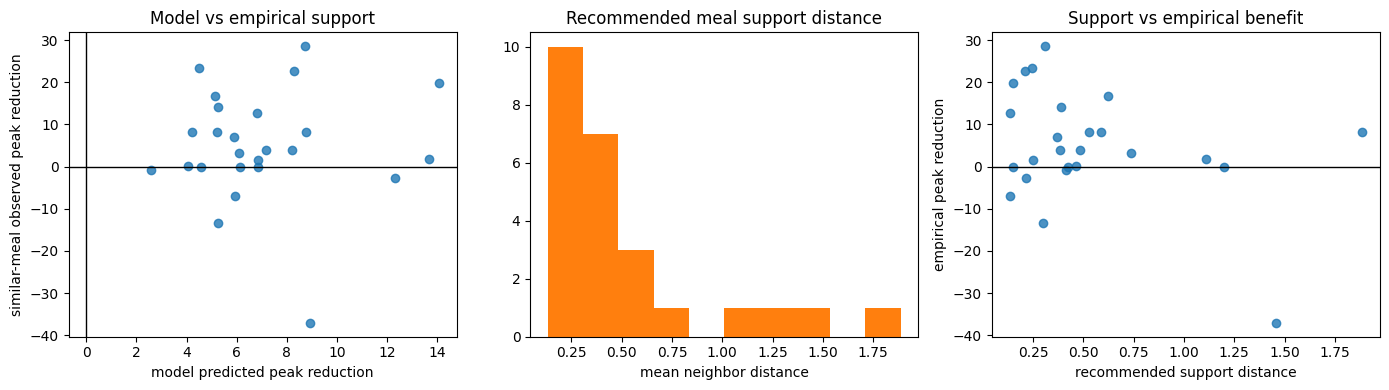

,idx,person_id,model_peak_delta,model_iAUC_delta,current_neighbor_peak_mean,recommended_neighbor_peak_mean,empirical_peak_delta,current_neighbor_iAUC_mean,recommended_neighbor_iAUC_mean,empirical_iAUC_delta,current_support_distance,recommended_support_distance,recommended_min_distance,n_recommended_neighbors_same_person
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,45.560000,51.240000,7.014266,980.889875,198.280000,193.356667,4.923333,6798.595833,6213.245833,585.350000,0.497675,0.526008,0.489592,0.200000
std,22.622039,48.335873,2.889057,418.770281,31.582334,33.890794,13.239162,1298.958028,1327.227267,1383.900925,0.451148,0.442656,0.452095,0.408248
min,12.000000,1.000000,2.583523,356.006359,144.750000,155.583333,-37.083333,4813.020833,3820.937500,-3009.270833,0.085082,0.132648,0.081646,0.000000
25%,34.000000,10.000000,5.201101,726.092831,172.333333,164.833333,0.000000,5696.041667,5221.562500,0.000000,0.203843,0.244594,0.191815,0.000000
50%,40.000000,10.000000,6.125414,860.082450,194.833333,183.083333,3.916667,6716.979167,6142.604167,667.812500,0.373660,0.388227,0.364116,0.000000
75%,61.000000,100.000000,8.278848,1125.577853,214.250000,211.500000,12.666667,7927.812500,6672.395833,1069.583333,0.555887,0.585595,0.559453,0.000000
max,78.000000,101.000000,14.060943,2010.330912,262.666667,259.416667,28.583333,8967.291667,9726.250000,3437.187500,1.883986,1.886928,1.870719,1.000000


In [ ]:
# =========================================================
# EMPIRICAL VALIDATION: DO SIMILAR REAL MEALS SUPPORT THE RECOMMENDATIONS?
# =========================================================


def build_observed_meal_response_table(ds, indices=None):
    if indices is None:
        indices = list(range(len(ds)))

    rows = []
    for idx in indices:
        sample = sample_from_dataset(ds, int(idx))
        baseline = float(np.median(sample["glucose"][sample["time"] < 0]))
        metrics = response_metrics(sample["time"], sample["glucose"], baseline=baseline)
        rows.append({
            "idx": int(idx),
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "meal_type": sample["meal_type"],
            **sample["meal"],
            **metrics,
        })

    return pd.DataFrame(rows)


def meal_similarity_features(sample, meal_override=None):
    meal = sample["meal"] if meal_override is None else meal_override
    baseline, slope = premeal_summary(sample)
    context = np.asarray(sample.get("context", np.zeros(5)), dtype=float)
    meal_type = context[2:5] if len(context) >= 5 else np.zeros(3)

    return np.array([
        float(meal["carbs"]) / 50.0,
        float(meal["fat"]) / 20.0,
        float(meal["protein"]) / 20.0,
        baseline / 40.0,
        slope / 0.20,
        *meal_type,
    ], dtype=float)


def observed_similarity_features(row):
    meal_type_vec = np.array([
        1.0 if str(row["meal_type"]).lower() == "breakfast" else 0.0,
        1.0 if str(row["meal_type"]).lower() == "lunch" else 0.0,
        1.0 if str(row["meal_type"]).lower() == "dinner" else 0.0,
    ])

    return np.array([
        float(row["carbs"]) / 50.0,
        float(row["fat"]) / 20.0,
        float(row["protein"]) / 20.0,
        float(row["baseline"]) / 40.0,
        0.0,
        *meal_type_vec,
    ], dtype=float)


def similar_observed_meals(sample, meal_override, observed_df, k=12, same_meal_type=True):
    target = meal_similarity_features(sample, meal_override=meal_override)
    candidates = observed_df.copy()
    candidates = candidates[candidates["idx"] != int(sample["idx"])]

    if same_meal_type:
        candidates = candidates[candidates["meal_type"].astype(str).str.lower() == str(sample["meal_type"]).lower()]
        if len(candidates) < k:
            candidates = observed_df[observed_df["idx"] != int(sample["idx"])].copy()

    distances = []
    for _, row in candidates.iterrows():
        vec = observed_similarity_features(row)
        distances.append(float(np.sqrt(np.mean((vec - target) ** 2))))

    candidates = candidates.assign(similarity_distance=distances)
    return candidates.sort_values("similarity_distance").head(k)


def validate_recommendations_with_similar_meals(ds, recommendation_eval, observed_df, max_meals=25, k=12):
    rows = []

    for _, rec_row in tqdm(recommendation_eval.head(max_meals).iterrows(), total=min(max_meals, len(recommendation_eval))):
        sample = sample_from_dataset(ds, int(rec_row["idx"]))
        candidate_lookup = dict(meal_redesign_candidates(sample["meal"]))
        best_label = rec_row["best_candidate"]
        best_meal = candidate_lookup[best_label]

        current_neighbors = similar_observed_meals(sample, sample["meal"], observed_df, k=k)
        recommended_neighbors = similar_observed_meals(sample, best_meal, observed_df, k=k)

        rows.append({
            "idx": int(rec_row["idx"]),
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "best_candidate": best_label,
            "model_peak_delta": rec_row["peak_delta"],
            "model_iAUC_delta": rec_row["iAUC_delta"],
            "current_neighbor_peak_mean": current_neighbors["peak"].mean(),
            "recommended_neighbor_peak_mean": recommended_neighbors["peak"].mean(),
            "empirical_peak_delta": current_neighbors["peak"].mean() - recommended_neighbors["peak"].mean(),
            "current_neighbor_iAUC_mean": current_neighbors["iAUC"].mean(),
            "recommended_neighbor_iAUC_mean": recommended_neighbors["iAUC"].mean(),
            "empirical_iAUC_delta": current_neighbors["iAUC"].mean() - recommended_neighbors["iAUC"].mean(),
            "current_support_distance": current_neighbors["similarity_distance"].mean(),
            "recommended_support_distance": recommended_neighbors["similarity_distance"].mean(),
            "recommended_min_distance": recommended_neighbors["similarity_distance"].min(),
            "n_recommended_neighbors_same_person": int((recommended_neighbors["person_id"] == sample["person_id"]).sum()),
        })

    return pd.DataFrame(rows)


observed_meal_response_df = build_observed_meal_response_table(mode2_dataset, indices=train_idx + test_idx)
recommendation_similar_meal_validation = validate_recommendations_with_similar_meals(
    mode2_dataset,
    mode2_recommendation_eval,
    observed_meal_response_df,
    max_meals=min(25, len(mode2_recommendation_eval)),
    k=12,
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(
    recommendation_similar_meal_validation["model_peak_delta"],
    recommendation_similar_meal_validation["empirical_peak_delta"],
    alpha=0.8,
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlabel("model predicted peak reduction")
axes[0].set_ylabel("similar-meal observed peak reduction")
axes[0].set_title("Model vs empirical support")

axes[1].hist(recommendation_similar_meal_validation["recommended_support_distance"], bins=10, color="tab:orange")
axes[1].set_title("Recommended meal support distance")
axes[1].set_xlabel("mean neighbor distance")

axes[2].scatter(
    recommendation_similar_meal_validation["recommended_support_distance"],
    recommendation_similar_meal_validation["empirical_peak_delta"],
    alpha=0.8,
)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_xlabel("recommended support distance")
axes[2].set_ylabel("empirical peak reduction")
axes[2].set_title("Support vs empirical benefit")

plt.tight_layout()
plt.show()

recommendation_similar_meal_validation.describe()


In [ ]:
# =========================================================
# SUPPORT-AWARE RECOMMENDATION SUMMARY
# =========================================================


def support_class(distance):
    distance = float(distance)
    if distance <= 0.35:
        return "strong empirical support"
    if distance <= 0.65:
        return "moderate empirical support"
    return "model extrapolation"


recommendation_support_summary_df = recommendation_similar_meal_validation.copy()
recommendation_support_summary_df["support_class"] = recommendation_support_summary_df["recommended_support_distance"].map(support_class)
recommendation_support_summary_df["empirical_peak_agrees"] = recommendation_support_summary_df["empirical_peak_delta"] > 0
recommendation_support_summary_df["empirical_iAUC_agrees"] = recommendation_support_summary_df["empirical_iAUC_delta"] > 0
recommendation_support_summary_df["support_penalized_peak_delta"] = (
    recommendation_support_summary_df["model_peak_delta"]
    - 8.0 * np.maximum(0.0, recommendation_support_summary_df["recommended_support_distance"] - 0.35)
)

support_class_summary = recommendation_support_summary_df.groupby("support_class").agg(
    n_meals=("idx", "count"),
    model_peak_delta_mean=("model_peak_delta", "mean"),
    empirical_peak_delta_mean=("empirical_peak_delta", "mean"),
    empirical_peak_agreement_rate=("empirical_peak_agrees", "mean"),
    empirical_iAUC_agreement_rate=("empirical_iAUC_agrees", "mean"),
    support_distance_mean=("recommended_support_distance", "mean"),
    support_penalized_peak_delta_mean=("support_penalized_peak_delta", "mean"),
).reset_index().sort_values("support_distance_mean")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(
    support_class_summary["support_class"],
    support_class_summary["empirical_peak_agreement_rate"],
    color="tab:green",
)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("fraction")
axes[0].set_title("Empirical peak agreement by support class")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(
    support_class_summary["support_class"],
    support_class_summary["support_penalized_peak_delta_mean"],
    color="tab:blue",
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("mg/dL")
axes[1].set_title("Support-penalized predicted peak benefit")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

support_class_summary


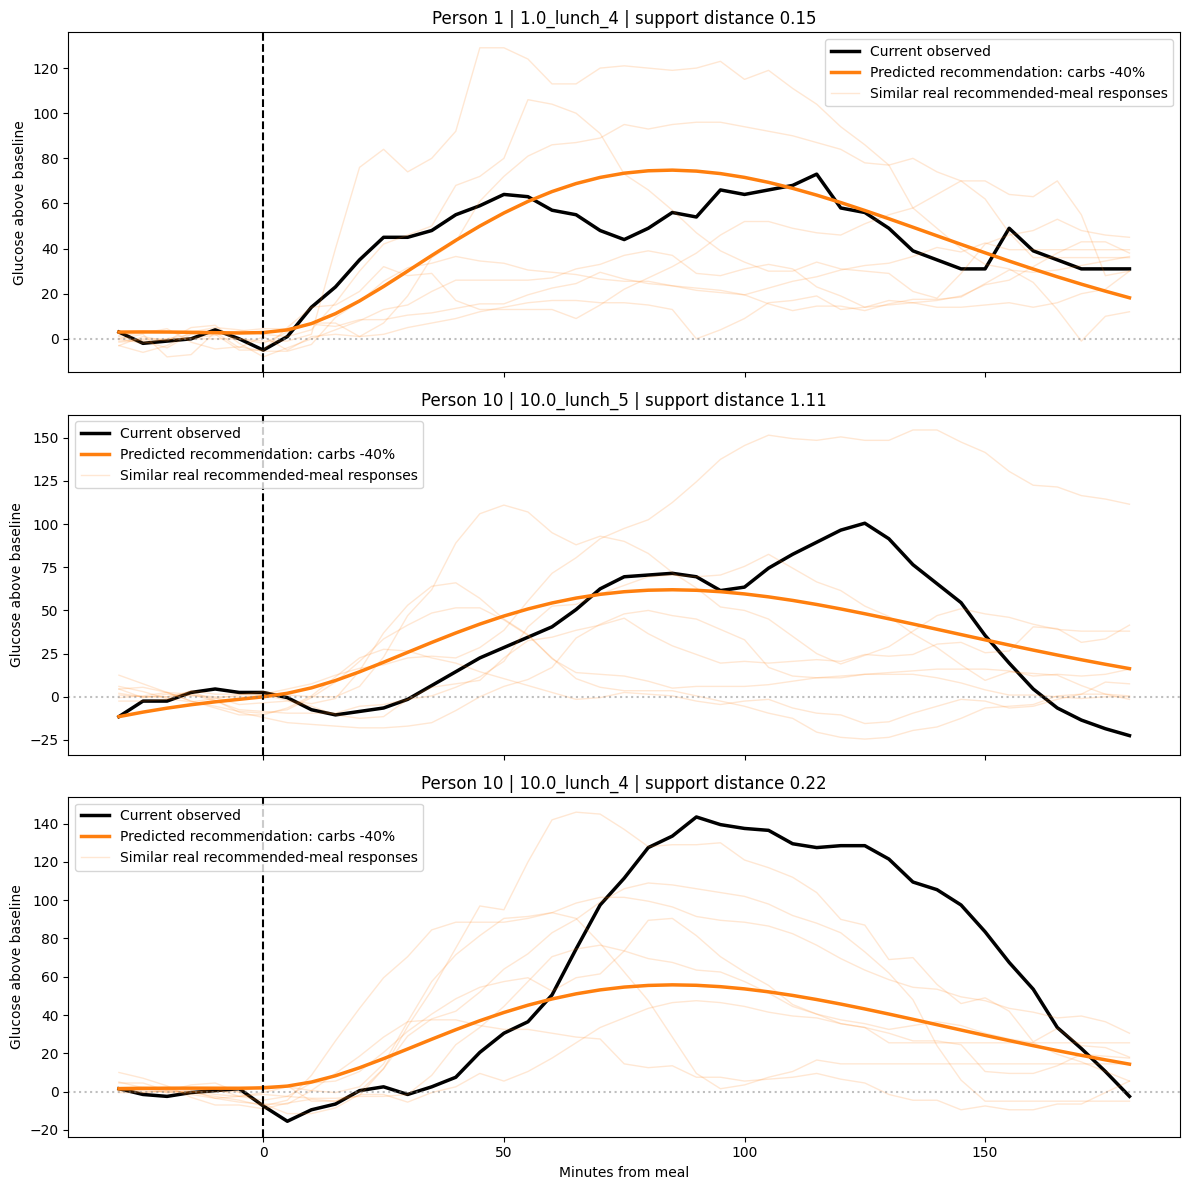

In [ ]:
# =========================================================
# PLOT RECOMMENDATIONS AGAINST SIMILAR REAL MEAL RESPONSES
# =========================================================


def plot_similar_meal_support_examples(ds, validation_df, observed_df, n_examples=3, k=8):
    examples = validation_df.sort_values("model_peak_delta", ascending=False).head(n_examples)
    fig, axes = plt.subplots(len(examples), 1, figsize=(12, 4 * len(examples)), sharex=True)

    if len(examples) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, examples.iterrows()):
        sample = sample_from_dataset(ds, int(row["idx"]))
        candidate_lookup = dict(meal_redesign_candidates(sample["meal"]))
        best_meal = candidate_lookup[row["best_candidate"]]
        rec_neighbors = similar_observed_meals(sample, best_meal, observed_df, k=k)

        best_sample = sample_with_meal(sample, best_meal)
        best_result, best_pred, _, _ = run_premeal_mode2_prediction(best_sample, n_A=15, n_T=15)

        baseline = float(np.median(sample["glucose"][sample["time"] < 0]))
        ax.plot(sample["time"], sample["glucose"] - baseline, color="black", linewidth=2.5, label="Current observed")
        ax.plot(best_result["time"], best_pred["mean"] - baseline, color="tab:orange", linewidth=2.5, label=f"Predicted recommendation: {row['best_candidate']}")

        for n, (_, neighbor) in enumerate(rec_neighbors.iterrows()):
            neighbor_sample = sample_from_dataset(ds, int(neighbor["idx"]))
            neighbor_baseline = float(np.median(neighbor_sample["glucose"][neighbor_sample["time"] < 0]))
            ax.plot(
                neighbor_sample["time"],
                neighbor_sample["glucose"] - neighbor_baseline,
                color="tab:orange",
                alpha=0.18,
                linewidth=1,
                label="Similar real recommended-meal responses" if n == 0 else None,
            )

        ax.axvline(0, linestyle="--", color="black")
        ax.axhline(0, linestyle=":", color="gray", alpha=0.5)
        ax.set_ylabel("Glucose above baseline")
        ax.set_title(
            f"Person {sample['person_id']} | {sample['meal_id']} | "
            f"support distance {row['recommended_support_distance']:.2f}"
        )
        ax.legend(loc="best")

    axes[-1].set_xlabel("Minutes from meal")
    plt.tight_layout()
    plt.show()


plot_similar_meal_support_examples(
    mode2_dataset,
    recommendation_similar_meal_validation,
    observed_meal_response_df,
    n_examples=3,
    k=8,
)


In [ ]:
# =========================================================
# TOP FINAL POSTERIOR COMBINATIONS FOR THE EXAMPLE
# =========================================================

final_post = result["posterior_history"][-1]
flat = final_post.reshape(-1)
order = np.argsort(flat)[::-1][:12]

rows = []
for flat_idx in order:
    t_idx, a_idx = np.unravel_index(flat_idx, final_post.shape)
    rows.append({
        "A_meal": result["A_grid"][a_idx],
        "T_meal": result["T_grid"][t_idx],
        "posterior_probability": flat[flat_idx],
    })

top_posterior_df = pd.DataFrame(rows)
top_posterior_df


,A_meal,T_meal,posterior_probability
0,0.133020,61.617647,0.376884
1,0.120073,66.764706,0.242449
2,0.120073,61.617647,0.185144
3,0.133020,56.470588,0.094625
4,0.147363,56.470588,0.035258
5,0.108386,66.764706,0.022784
6,0.133020,66.764706,0.016970
7,0.108386,71.911765,0.009174
8,0.120073,71.911765,0.005288
9,0.147363,51.323529,0.003492
